In [1]:
#All libraries import here
import torch
import torch.nn as nn
import torch.optim as optim
import requests
import json
import pandas as pd
import datetime as dt
import seaborn as sns
import time
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import matplotlib.pyplot as plt
import ray
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import copy
from ray import tune
from ray.tune import CLIReporter
from ray.tune.schedulers import ASHAScheduler
from sklearn.model_selection import train_test_split
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy.stats import shapiro, normaltest, jarque_bera
from hurst import compute_Hc
from functools import partial
import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from scipy.stats import normaltest
import optuna
from optuna.samplers import TPESampler
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import random
import time
from scipy.optimize import curve_fit
from scipy.special import expit
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import matplotlib.dates as mdates

## Data load in

In [2]:
df = pd.read_csv('BTCUSDT_full_features.csv', index_col='Date', parse_dates=True)
df

,log_return,ETH_LogReturns,Volatility,RSI_14,ATR_14,blocksize,cost_per_transaction,difficulty,hash_rate,n_payments_per_block,n_transactions_per_block,n_transactions_total,avgblocksize
Date,,,,,,,,,,,,,
2018-01-16,-0.216880,0.425497,0.468509,0.305204,0.316867,0.000000,0.301796,0.000000,0.001913,0.262038,0.229748,0.000000,0.295511
2018-01-17,0.008113,0.716421,0.188175,0.295717,0.334373,0.000286,0.264873,0.000000,0.002600,0.253494,0.225611,0.000288,0.301318
2018-01-18,-0.002444,0.709120,0.047973,0.286157,0.335334,0.000590,0.306980,0.000000,0.003115,0.233811,0.203865,0.000588,0.295890
2018-01-19,0.045737,0.762522,0.048095,0.186188,0.321884,0.000902,0.364494,0.000000,0.002428,0.158291,0.137143,0.000882,0.294700
2018-01-20,0.109271,0.850073,0.054298,0.275093,0.328421,0.001198,0.423503,0.000000,0.003544,0.129746,0.110513,0.001112,0.322508
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-22,0.023845,0.740642,0.005239,0.676593,0.409602,0.998542,0.147500,0.867455,0.672572,0.540845,0.706638,0.997949,0.551124
2026-04-23,0.001013,0.693824,0.001336,0.665020,0.398095,0.998898,0.169929,0.867455,0.620335,0.510756,0.617384,0.998461,0.533958
2026-04-24,-0.010538,0.708445,0.000785,0.609541,0.389963,0.999219,0.157646,0.867455,0.766599,0.525360,0.666746,0.998889,0.543127


In [3]:
# Train/Val/Test split 70/15/15
train_size = int(len(df) * 0.70)
val_size = int(len(df) * 0.15)
test_size = len(df) - train_size - val_size

train_df = df.iloc[:train_size]
val_df = df.iloc[train_size:train_size + val_size]
test_df = df.iloc[train_size + val_size:]

print(f"Train: {train_df.index[0].date()} to {train_df.index[-1].date()} ({len(train_df)} rows)")
print(f"Val:   {val_df.index[0].date()} to {val_df.index[-1].date()} ({len(val_df)} rows)")
print(f"Test:  {test_df.index[0].date()} to {test_df.index[-1].date()} ({len(test_df)} rows)")


Train: 2018-01-16 to 2023-11-01 (2116 rows)
Val:   2023-11-02 to 2025-01-27 (453 rows)
Test:  2025-01-28 to 2026-04-26 (454 rows)


In [17]:
def hybrid_qrnn_loss(y, q_hybrid, sigma_al, alpha):
    """
    Hybrid QRNN ALD NLL Loss
    y        : observed returns (tensor), shape (T,)
    q_hybrid : hybrid quantile estimate (tensor), shape (T,)
    sigma_al : scale parameter (scalar tensor)
    alpha    : quantile level in (0,1)
    """
    # Residual
    u = y - q_hybrid

    # Quantile check (pinball) loss
    indicator = (u < 0).float()
    rho_alpha = u * (alpha - indicator)

    # ALD NLL
    nll = (- torch.log(torch.tensor(alpha * (1 - alpha), dtype=torch.float32))
           + torch.log(sigma_al)          # sigma_al is already a tensor — no wrapping needed
           + rho_alpha / sigma_al)

    return nll.mean()

In [7]:
def compute_hybrid_quantile_location_self(y, X, beta1, beta2, fnn_model, psi):
    """
    Hybrid QRNN location parameter -- self-lagged.
    The CaViaR component uses the previous pure CaViaR output as its autoregressive input,
    keeping the statistical and FNN components separated.
    y      : raw log returns (T,)
    X      : normalised features (T, input_dim)
    beta1  : quantile persistence, constrained to (0,1)
    beta2  : magnitude impact, constrained to >=0
    psi    : mixing weight, constrained to (0,1)
    fnn_model : FNN correction network
    """
    T = len(y)
    fnn_out = fnn_model(X).squeeze(-1)  # shape (T,)

    q_caviar_list = [torch.zeros(1)]
    q_hybrid_list = [torch.zeros(1)]

    for t in range(1, T):
        # CaViaR component -- self-lagged: uses previous pure CaViaR output
        caviar_t = beta1 * q_caviar_list[t-1] + beta2 * torch.abs(y[t-1])
        q_caviar_list.append(caviar_t)

        # Hybrid combination
        hybrid_t = psi * caviar_t + (1 - psi) * fnn_out[t]
        q_hybrid_list.append(hybrid_t)

    q_caviar = torch.stack(q_caviar_list).squeeze(-1)
    q_hybrid = torch.stack(q_hybrid_list).squeeze(-1)

    return q_hybrid, q_caviar

In [13]:
# Feature columns for FNN input
feature_cols = ['Volatility', 'RSI_14', 'ATR_14', 'ETH_LogReturns',
                'blocksize', 'cost_per_transaction', 'difficulty',
                'hash_rate', 'n_payments_per_block',
                'n_transactions_per_block', 'n_transactions_total',
                'avgblocksize']

# Convert to tensors
y_train = torch.tensor(train_df['log_return'].values, dtype=torch.float32)
y_val = torch.tensor(val_df['log_return'].values, dtype=torch.float32)
X_train = torch.tensor(train_df[feature_cols].values, dtype=torch.float32)
X_val = torch.tensor(val_df[feature_cols].values, dtype=torch.float32)

## Hyperparameter tuning

In [19]:
class HybridQRNN(nn.Module):
    def __init__(self, input_dim, config):
        super().__init__()

        # Fixed initialisations -- estimated during training, not tuned by Optuna
        self.beta1_raw = nn.Parameter(torch.tensor(1.386))   # sigmoid → 0.80
        self.beta2_raw = nn.Parameter(torch.tensor(0.3))
        self.psi_raw   = nn.Parameter(torch.tensor(0.0))     # sigmoid → 0.50
        self.sigma_raw = nn.Parameter(torch.tensor(0.5))

        # Build FNN
        layers = []
        prev_dim = input_dim
        n_hidden = config['n_hidden_layers']

        for i in range(n_hidden):
            hidden_dim = config[f'hidden_dim_{i}']
            layers.append(nn.Linear(prev_dim, hidden_dim))
            if config['layernorm']:
                layers.append(nn.LayerNorm(hidden_dim))
            layers.append(self._get_activation(config['activation']))
            if config['dropout'] > 0:
                layers.append(nn.Dropout(config['dropout']))
            prev_dim = hidden_dim

        layers.append(nn.Linear(prev_dim, 1))
        self.fnn = nn.Sequential(*layers)

        for m in self.fnn.modules():
            if isinstance(m, nn.Linear):
                if config['weight_init'] == 'glorot':
                    nn.init.xavier_uniform_(m.weight)
                elif config['weight_init'] == 'he':
                    nn.init.kaiming_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def _get_activation(self, name):
        return {
            'relu': nn.ReLU(),
            'elu': nn.ELU(),
            'gelu': nn.GELU(),
            'tanh': nn.Tanh()
        }.get(name, nn.ReLU())

    def forward(self, y, X):
        beta1 = torch.sigmoid(self.beta1_raw)
        beta2 = torch.nn.functional.softplus(self.beta2_raw)
        psi   = torch.sigmoid(self.psi_raw)
        sigma = torch.nn.functional.softplus(self.sigma_raw)

        # self-lagged: uses previous pure CaViaR output
        q_hybrid, q_caviar = compute_hybrid_quantile_location_self(
            y, X, beta1, beta2, self.fnn, psi
        )

        return q_hybrid, sigma


def compute_crp(y, q, alpha):
    """
    Coverage Ratio Penalty (CRP).
    For alpha <= 0.5: count violations where y <= q (lower tail).
    For alpha >  0.5: count violations where y >  q (upper tail).
    CRP = empirical_coverage / alpha*
    Penalty = (CRP - 1)^2
    """
    if alpha <= 0.5:
        empirical  = (y <= q).float().mean().item()
        alpha_star = alpha
    else:
        empirical  = (y > q).float().mean().item()
        alpha_star = 1.0 - alpha

    crp     = empirical / alpha_star
    penalty = (crp - 1.0) ** 2
    return crp, penalty


def objective_qrnn(trial, alpha):
    # Optuna only tunes architecture and training hyperparameters
    config = {
        'n_hidden_layers': trial.suggest_int('n_hidden_layers', 1, 3),
        'activation':      trial.suggest_categorical('activation', ['relu', 'elu', 'gelu', 'tanh']),
        'dropout':         trial.suggest_float('dropout', 0.0, 0.5),
        'layernorm':       trial.suggest_categorical('layernorm', [True, False]),
        'weight_init':     trial.suggest_categorical('weight_init', ['glorot', 'he']),
        'lr':              trial.suggest_float('lr', 1e-4, 5e-2, log=True),
        'optimizer':       trial.suggest_categorical('optimizer', ['adam', 'adamw']),
        'batch_size':      trial.suggest_categorical('batch_size', [32, 64, 128]),
        'weight_decay':    trial.suggest_float('weight_decay', 0.0, 1e-4),
        'gradient_clip':   trial.suggest_categorical('gradient_clip', [0.1, 1.0, 5.0]),
        'patience':        trial.suggest_categorical('patience', [10, 20, 30]),
    }

    for i in range(config['n_hidden_layers']):
        config[f'hidden_dim_{i}'] = trial.suggest_int(f'hidden_dim_{i}', 32, 256)

    input_dim = X_train.shape[1]
    torch.manual_seed(2026)
    model = HybridQRNN(input_dim, config)

    if config['optimizer'] == 'adam':
        optimizer = torch.optim.Adam(model.parameters(), lr=config['lr'],
                                     weight_decay=config['weight_decay'])
    else:
        optimizer = torch.optim.AdamW(model.parameters(), lr=config['lr'],
                                      weight_decay=config['weight_decay'])

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=10, factor=0.5, min_lr=1e-6)

    best_val_loss    = float('inf')
    patience_counter = 0
    patience         = config['patience']
    max_epochs       = 200
    best_model_state = None

    for epoch in range(max_epochs):
        model.train()
        optimizer.zero_grad()
        q_hybrid, sigma = model(y_train, X_train)
        loss = hybrid_qrnn_loss(y_train, q_hybrid, sigma, alpha)

        if torch.isnan(loss) or torch.isinf(loss):
            return float('inf')

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), config['gradient_clip'])
        optimizer.step()

        # early stopping uses NLL only
        model.eval()
        with torch.no_grad():
            q_val, sigma_val = model(y_val, X_val)
            val_loss = hybrid_qrnn_loss(y_val, q_val, sigma_val, alpha)

        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss    = val_loss.item()
            patience_counter = 0
            best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    # compute NLL and CRP after best model loaded
    with torch.no_grad():
        q_val, sigma_val = model(y_val, X_val)
        val_loss         = hybrid_qrnn_loss(y_val, q_val, sigma_val, alpha)
        crp, crp_penalty = compute_crp(y_val, q_val, alpha)

        beta1 = torch.sigmoid(model.beta1_raw).item()
        beta2 = torch.nn.functional.softplus(model.beta2_raw).item()
        psi   = torch.sigmoid(model.psi_raw).item()
        sigma = torch.nn.functional.softplus(model.sigma_raw).item()

    # store NLL and CRP in trial user_attrs for ranking after all trials finish
    trial.set_user_attr('nll',         val_loss.item())
    trial.set_user_attr('crp',         crp)
    trial.set_user_attr('crp_penalty', crp_penalty)
    trial.set_user_attr('beta1',       beta1)
    trial.set_user_attr('beta2',       beta2)
    trial.set_user_attr('psi',         psi)
    trial.set_user_attr('sigma',       sigma)

    print(f"  Trial {trial.number}: "
          f"NLL={val_loss.item():.4f} | "
          f"CRP={crp:.4f} | "
          f"CRP_penalty={crp_penalty:.4f} | "
          f"alpha={alpha} | lr={config['lr']:.5f} | "
          f"layers={config['n_hidden_layers']} | "
          f"activation={config['activation']} | "
          f"dropout={config['dropout']:.3f} | "
          f"psi={psi:.4f} | sigma={sigma:.4f} | "
          f"beta1={beta1:.4f} | beta2={beta2:.4f}")

    return val_loss.item()


def select_best_trial_by_rank(study):
    """
    Rank all completed trials by NLL and CRP_penalty separately.
    Select trial with lowest sum of ranks.
    Tiebreak: raw NLL, then raw CRP_penalty, then trial number.
    """
    trials = [t for t in study.trials
              if t.state == optuna.trial.TrialState.COMPLETE
              and t.value != float('inf')]

    for t in trials:
        t._nll         = t.user_attrs['nll']
        t._crp_penalty = t.user_attrs['crp_penalty']

    sorted_by_nll = sorted(trials, key=lambda t: t._nll)
    for rank, t in enumerate(sorted_by_nll, start=1):
        t._rank_nll = rank

    sorted_by_crp = sorted(trials, key=lambda t: t._crp_penalty)
    for rank, t in enumerate(sorted_by_crp, start=1):
        t._rank_crp = rank

    best = min(trials, key=lambda t: (
        t._rank_nll + t._rank_crp,
        t._nll,
        t._crp_penalty,
        t.number
    ))

    return best, trials


# -------------------------
# Run tuning for each alpha level
# -------------------------
alpha_levels      = [0.025, 0.050, 0.250, 0.500, 0.750, 0.950, 0.975]
base_seed         = 2026
best_configs_qrnn = {}

for i, alpha in enumerate(alpha_levels):
    print(f"\n{'='*60}")
    print(f"Tuning for alpha = {alpha} (seed = {base_seed + i})")
    print(f"{'='*60}")

    sampler = TPESampler(seed=base_seed + i)
    study   = optuna.create_study(direction='minimize', sampler=sampler)
    study.optimize(lambda trial, a=alpha: objective_qrnn(trial, alpha=a),
                   n_trials=200, show_progress_bar=True)

    # rank-based selection after all trials finish
    best_trial, all_trials = select_best_trial_by_rank(study)

    # print ranking summary -- top 10
    print(f"\nRanking summary for alpha={alpha}:")
    print(f"  {'Trial':>6} {'NLL':>8} {'NLL_rank':>9} {'CRP_pen':>9} {'CRP_rank':>9} {'Sum_rank':>9}")
    sorted_trials = sorted(all_trials, key=lambda t: t._rank_nll + t._rank_crp)
    for t in sorted_trials[:10]:
        print(f"  {t.number:>6} {t._nll:>8.4f} {t._rank_nll:>9} "
              f"{t._crp_penalty:>9.4f} {t._rank_crp:>9} "
              f"{t._rank_nll + t._rank_crp:>9}")

    # save full ranking for all trials to CSV
    ranking_records = []
    for t in all_trials:
        record = {
            'alpha':       alpha,
            'trial':       t.number,
            'nll':         t._nll,
            'crp':         t.user_attrs['crp'],
            'crp_penalty': t._crp_penalty,
            'rank_nll':    t._rank_nll,
            'rank_crp':    t._rank_crp,
            'sum_rank':    t._rank_nll + t._rank_crp,
            'beta1':       t.user_attrs['beta1'],
            'beta2':       t.user_attrs['beta2'],
            'psi':         t.user_attrs['psi'],
            'sigma':       t.user_attrs['sigma'],
        }
        record.update(t.params)
        ranking_records.append(record)

    ranking_df = pd.DataFrame(ranking_records)
    ranking_df = ranking_df.sort_values('sum_rank')
    ranking_df.to_csv(f'qrnn_self_ranking_alpha_{alpha}.csv', index=False)
    print(f"  Full ranking saved to qrnn_self_ranking_alpha_{alpha}.csv")

    best_configs_qrnn[alpha] = best_trial.params.copy()
    best_configs_qrnn[alpha]['alpha'] = alpha

    # re-run best config to extract estimated parameters
    torch.manual_seed(2026)
    best_model = HybridQRNN(X_train.shape[1], best_configs_qrnn[alpha])

    if best_configs_qrnn[alpha]['optimizer'] == 'adam':
        optimizer = torch.optim.Adam(best_model.parameters(),
                                     lr=best_configs_qrnn[alpha]['lr'],
                                     weight_decay=best_configs_qrnn[alpha]['weight_decay'])
    else:
        optimizer = torch.optim.AdamW(best_model.parameters(),
                                      lr=best_configs_qrnn[alpha]['lr'],
                                      weight_decay=best_configs_qrnn[alpha]['weight_decay'])

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=10, factor=0.5, min_lr=1e-6)

    best_val_loss    = float('inf')
    patience_counter = 0
    best_model_state = None

    for epoch in range(200):
        best_model.train()
        optimizer.zero_grad()
        q_hybrid, sigma = best_model(y_train, X_train)
        loss = hybrid_qrnn_loss(y_train, q_hybrid, sigma, alpha)
        if torch.isnan(loss) or torch.isinf(loss):
            break
        loss.backward()
        nn.utils.clip_grad_norm_(best_model.parameters(),
                                  best_configs_qrnn[alpha]['gradient_clip'])
        optimizer.step()

        best_model.eval()
        with torch.no_grad():
            q_val, sigma_val = best_model(y_val, X_val)
            val_loss = hybrid_qrnn_loss(y_val, q_val, sigma_val, alpha)
        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss    = val_loss.item()
            patience_counter = 0
            best_model_state = {k: v.clone() for k, v in best_model.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= best_configs_qrnn[alpha].get('patience', 20):
                break

    if best_model_state is not None:
        best_model.load_state_dict(best_model_state)

    with torch.no_grad():
        q_val_final, sigma_val_final = best_model(y_val, X_val)
        final_nll                    = hybrid_qrnn_loss(y_val, q_val_final, sigma_val_final, alpha).item()
        final_crp, final_crp_penalty = compute_crp(y_val, q_val_final, alpha)

        est_beta1 = torch.sigmoid(best_model.beta1_raw).item()
        est_beta2 = torch.nn.functional.softplus(best_model.beta2_raw).item()
        est_psi   = torch.sigmoid(best_model.psi_raw).item()
        est_sigma = torch.nn.functional.softplus(best_model.sigma_raw).item()

    best_configs_qrnn[alpha]['est_psi']   = est_psi
    best_configs_qrnn[alpha]['est_sigma'] = est_sigma
    best_configs_qrnn[alpha]['est_beta1'] = est_beta1
    best_configs_qrnn[alpha]['est_beta2'] = est_beta2
    best_configs_qrnn[alpha]['est_crp']   = final_crp

    print(f"\nBest trial (rank-based): #{best_trial.number}")
    print(f"  NLL rank:   {best_trial._rank_nll} | CRP rank: {best_trial._rank_crp} | "
          f"Sum: {best_trial._rank_nll + best_trial._rank_crp}")
    print(f"Final NLL:          {final_nll:.4f}")
    print(f"Final CRP:          {final_crp:.4f}")
    print(f"Final CRP penalty:  {final_crp_penalty:.4f}")
    print(f"Best params: {best_trial.params}")
    print(f"Estimated psi:   {est_psi:.4f}")
    print(f"Estimated sigma: {est_sigma:.4f}")
    print(f"Estimated beta1: {est_beta1:.4f}")
    print(f"Estimated beta2: {est_beta2:.4f}")

print("\n" + "="*60)
print("TUNING COMPLETE — BEST CONFIGS PER ALPHA (SELF-LAGGED, 200 TRIALS)")
print("="*60)
for alpha, config in best_configs_qrnn.items():
    print(f"alpha={alpha}: {config}")

[I 2026-07-06 12:52:33,986] A new study created in memory with name: no-name-aae65557-c859-4fb5-b5b6-9a8ffd2303a1



Tuning for alpha = 0.025 (seed = 2026)


  0%|          | 0/200 [00:00<?, ?it/s]

  Trial 0: NLL=3.6923 | CRP=0.1766 | CRP_penalty=0.6780 | alpha=0.025 | lr=0.00066 | layers=1 | activation=elu | dropout=0.494 | psi=0.5002 | sigma=0.9737 | beta1=0.7998 | beta2=0.8540
[I 2026-07-06 12:52:36,312] Trial 0 finished with value: 3.6923327445983887 and parameters: {'n_hidden_layers': 1, 'activation': 'elu', 'dropout': 0.49377524711883497, 'layernorm': False, 'weight_init': 'he', 'lr': 0.0006552020421842752, 'optimizer': 'adam', 'batch_size': 32, 'weight_decay': 5.618938892024055e-05, 'gradient_clip': 5.0, 'patience': 30, 'hidden_dim_0': 176}. Best is trial 0 with value: 3.6923327445983887.
  Trial 1: NLL=3.6977 | CRP=0.0883 | CRP_penalty=0.8312 | alpha=0.025 | lr=0.00050 | layers=1 | activation=relu | dropout=0.341 | psi=0.5001 | sigma=0.9738 | beta1=0.7999 | beta2=0.8541
[I 2026-07-06 12:52:38,909] Trial 1 finished with value: 3.6977035999298096 and parameters: {'n_hidden_layers': 1, 'activation': 'relu', 'dropout': 0.3412887415864622, 'layernorm': True, 'weight_init': 'gl

[I 2026-07-06 13:42:16,810] A new study created in memory with name: no-name-4cec4f4a-ba8d-450a-a6c5-c206835ab2b1


...

  Trial 0: NLL=1.8887 | CRP=1.8543 | CRP_penalty=0.7298 | alpha=0.95 | lr=0.00703 | layers=2 | activation=tanh | dropout=0.112 | psi=0.5334 | sigma=0.3120 | beta1=0.7579 | beta2=0.6425
[I 2026-07-06 18:46:21,295] Trial 0 finished with value: 1.8887486457824707 and parameters: {'n_hidden_layers': 2, 'activation': 'tanh', 'dropout': 0.11155263989652436, 'layernorm': False, 'weight_init': 'glorot', 'lr': 0.007027131382827591, 'optimizer': 'adam', 'batch_size': 64, 'weight_decay': 3.1297438535544123e-06, 'gradient_clip': 1.0, 'patience': 10, 'hidden_dim_0': 187, 'hidden_dim_1': 217}. Best is trial 0 with value: 1.8887486457824707.
  Trial 1: NLL=2.1817 | CRP=1.6777 | CRP_penalty=0.4593 | alpha=0.95 | lr=0.00544 | layers=2 | activation=tanh | dropout=0.041 | psi=0.5264 | sigma=0.4189 | beta1=0.7766 | beta2=0.7268
[I 2026-07-06 18:46:37,499] Trial 1 finished with value: 2.1817197799682617 and parameters: {'n_hidden_layers': 2, 'activation': 'tanh', 'dropout': 0.04083183838368104, 'layernorm'

[I 2026-07-06 19:36:35,784] A new study created in memory with name: no-name-b97ee576-b95f-46fb-9b99-7f5aea492676



Best trial (rank-based): #120
  NLL rank:   3 | CRP rank: 2 | Sum: 5
Final NLL:          -2.3681
Final CRP:          1.0155
Final CRP penalty:  0.0002
Best params: {'n_hidden_layers': 1, 'activation': 'tanh', 'dropout': 0.12559506116978175, 'layernorm': False, 'weight_init': 'glorot', 'lr': 0.04540956074890765, 'optimizer': 'adamw', 'batch_size': 128, 'weight_decay': 3.3020566277769656e-05, 'gradient_clip': 1.0, 'patience': 20, 'hidden_dim_0': 149}
Estimated psi:   0.9501
Estimated sigma: 0.0025
Estimated beta1: 0.6178
Estimated beta2: 0.0853

Tuning for alpha = 0.975 (seed = 2032)


  0%|          | 0/200 [00:00<?, ?it/s]

  Trial 0: NLL=2.4816 | CRP=0.0000 | CRP_penalty=1.0000 | alpha=0.975 | lr=0.00741 | layers=3 | activation=relu | dropout=0.111 | psi=0.5238 | sigma=0.2899 | beta1=0.7466 | beta2=0.6324
[I 2026-07-06 19:36:51,925] Trial 0 finished with value: 2.4816012382507324 and parameters: {'n_hidden_layers': 3, 'activation': 'relu', 'dropout': 0.11110238679748752, 'layernorm': False, 'weight_init': 'he', 'lr': 0.007412946243424984, 'optimizer': 'adam', 'batch_size': 128, 'weight_decay': 7.766054095562223e-05, 'gradient_clip': 1.0, 'patience': 20, 'hidden_dim_0': 195, 'hidden_dim_1': 201, 'hidden_dim_2': 229}. Best is trial 0 with value: 2.4816012382507324.
  Trial 1: NLL=3.6754 | CRP=0.0000 | CRP_penalty=1.0000 | alpha=0.975 | lr=0.00011 | layers=1 | activation=elu | dropout=0.061 | psi=0.5022 | sigma=0.9562 | beta1=0.8011 | beta2=0.8584
[I 2026-07-06 19:37:06,732] Trial 1 finished with value: 3.6754229068756104 and parameters: {'n_hidden_layers': 1, 'activation': 'elu', 'dropout': 0.0611759513356


TEST SET METRICS -- QRNN S Self-lagged
   alpha        NLL            HRE
  ----------------------------------
   0.025    -2.2535       0.005176
    0.05    -2.3925       0.029295
    0.25    -2.7295       0.080396
     0.5    -2.8186       0.092511
    0.75    -2.5777       0.166300
    0.95    -2.3522       0.027974
   0.975    -2.1174       0.025000
  ----------------------------------
    Mean    -2.4631       0.060950

  --> Average NLL: -2.4631
  --> Average HRE: 0.060950


In [25]:
configs_rows = []
for tau, config in best_configs_qrnn.items():
    row = {'tau': tau}
    row.update(config)
    configs_rows.append(row)

configs_df = pd.DataFrame(configs_rows)
configs_df = configs_df.set_index('tau')
configs_df

,n_hidden_layers,activation,dropout,layernorm,weight_init,lr,optimizer,batch_size,weight_decay,gradient_clip,patience,hidden_dim_0,hidden_dim_1,alpha,est_psi,est_sigma,est_beta1,est_beta2,est_crp
tau,,,,,,,,,,,,,,,,,,,
0.025,2,gelu,0.280124,True,he,0.049730,adamw,128,0.000066,1.0,20,71,139.0,0.025,0.935867,0.001499,0.288768,0.048626,0.971302
0.050,2,tanh,0.174579,True,he,0.049106,adamw,64,0.000013,0.1,20,79,97.0,0.050,0.947574,0.002520,0.310281,0.055938,1.103753
0.250,1,elu,0.182280,False,he,0.039616,adamw,128,0.000037,5.0,30,63,NaN,0.250,0.881001,0.006662,0.453050,0.091984,1.015453
0.500,1,tanh,0.240414,False,he,0.042744,adamw,128,0.000046,5.0,30,248,NaN,0.500,0.917835,0.008254,0.509241,0.117971,1.002208
0.750,1,gelu,0.395175,False,glorot,0.044097,adam,64,0.000038,1.0,30,42,NaN,0.750,0.882119,0.007601,0.559151,0.075298,0.988962
0.950,1,tanh,0.125595,False,glorot,0.045410,adamw,128,0.000033,1.0,20,149,NaN,0.950,0.950073,0.002520,0.617803,0.085255,1.015453
0.975,2,relu,0.219802,False,he,0.049906,adam,128,0.000021,1.0,20,54,238.0,0.975,0.811584,0.001755,0.665438,0.077560,0.971302



Training final model for alpha = 0.025 (self-lagged)
  Epoch 50: train=3.3564, val=3.3487
  Epoch 100: train=2.9469, val=2.9370
  Epoch 150: train=2.4821, val=2.4705
  Epoch 200: train=1.9856, val=1.9745
  Test loss: 1.9743 | Coverage ratio: 0.352

Training final model for alpha = 0.05 (self-lagged)
  Epoch 50: train=2.6914, val=2.6829
  Epoch 100: train=2.2747, val=2.2632
  Epoch 150: train=1.8299, val=1.8344
  Epoch 200: train=1.3315, val=1.3172
  Test loss: 1.3172 | Coverage ratio: 0.176

Training final model for alpha = 0.25 (self-lagged)
  Epoch 50: train=1.3402, val=1.3245
  Epoch 100: train=0.9141, val=0.8976
  Epoch 150: train=0.4529, val=0.4419
  Epoch 200: train=-0.0414, val=-0.0605
  Test loss: -0.0665 | Coverage ratio: 1.225

Training final model for alpha = 0.5 (self-lagged)
  Epoch 50: train=1.0382, val=1.0198
  Epoch 100: train=0.6220, val=0.6065
  Epoch 150: train=0.1676, val=0.1489
  Epoch 200: train=-0.3177, val=-0.3339
  Test loss: -0.3259 | Coverage ratio: 1.789

T

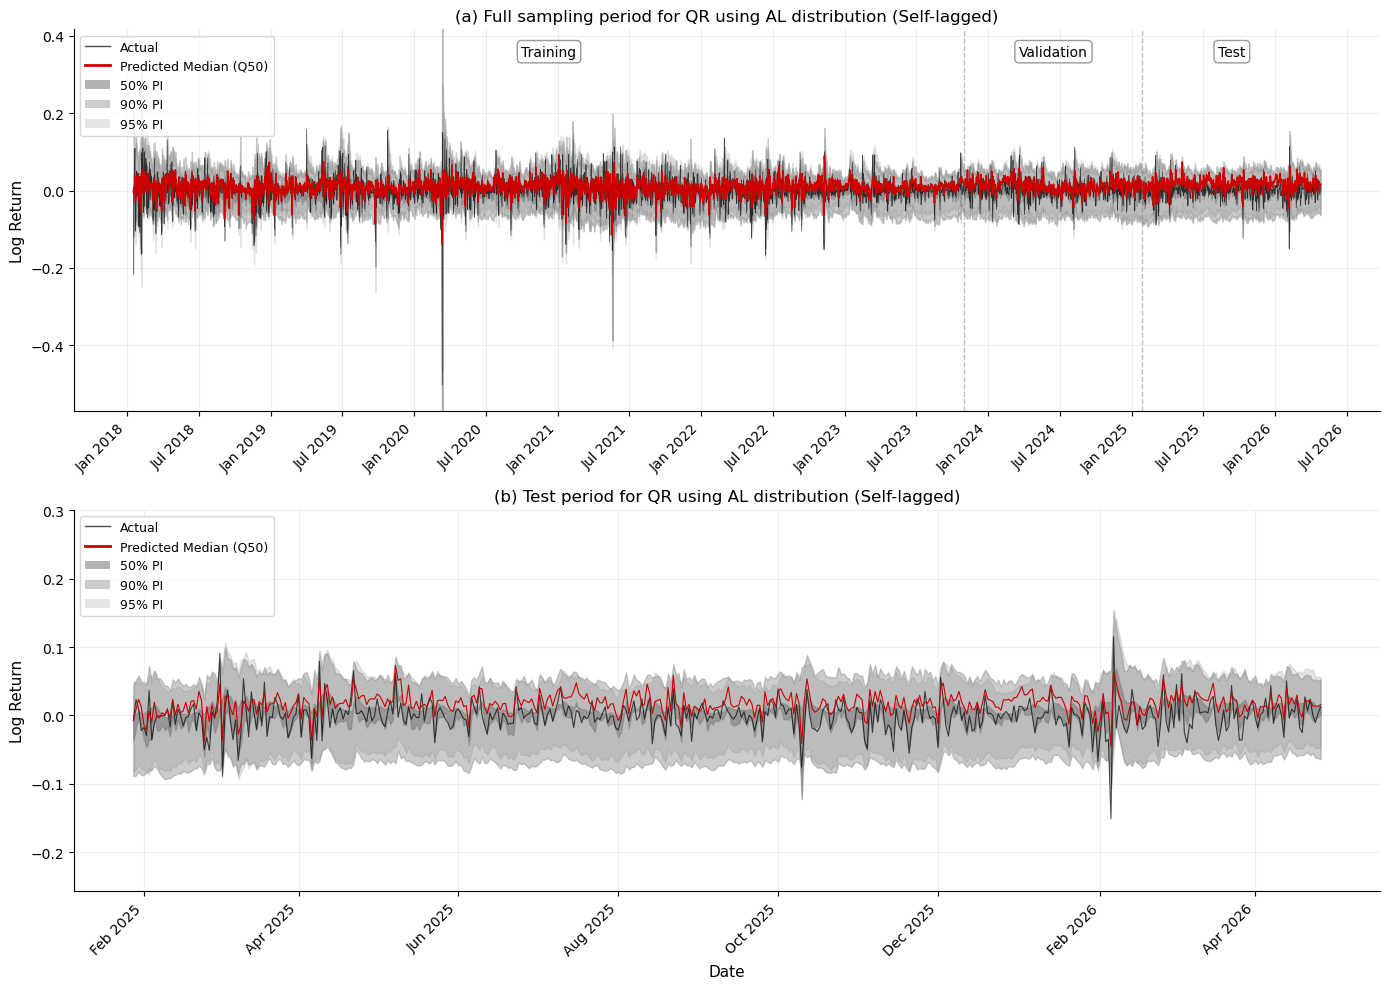

In [34]:
def train_final_model_qrnn(alpha, config, y_train, X_train, y_val, X_val, y_test, X_test):
    torch.manual_seed(2026)
    input_dim = X_train.shape[1]
    model = HybridQRNN(input_dim, config)

    if config['optimizer'] == 'adam':
        optimizer = torch.optim.Adam(model.parameters(), lr=config['lr'],
                                     weight_decay=config['weight_decay'])
    else:
        optimizer = torch.optim.AdamW(model.parameters(), lr=config['lr'],
                                      weight_decay=config['weight_decay'])

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=10, factor=0.5, min_lr=1e-6)

    best_val_loss    = float('inf')
    patience_counter = 0
    patience         = 30
    max_epochs       = 200
    best_model_state = None
    train_losses, val_losses = [], []

    for epoch in range(max_epochs):
        model.train()
        optimizer.zero_grad()
        q_hybrid, sigma = model(y_train, X_train)
        loss = hybrid_qrnn_loss(y_train, q_hybrid, sigma, alpha)

        if torch.isnan(loss) or torch.isinf(loss):
            print(f"  NaN/Inf at epoch {epoch}, stopping")
            break

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), config['gradient_clip'])
        optimizer.step()
        train_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            q_val, sigma_val = model(y_val, X_val)
            val_loss = hybrid_qrnn_loss(y_val, q_val, sigma_val, alpha)

        val_losses.append(val_loss.item())
        scheduler.step(val_loss)

        if (epoch + 1) % 50 == 0:
            print(f"  Epoch {epoch+1}: train={loss.item():.4f}, val={val_loss.item():.4f}")

        if val_loss < best_val_loss:
            best_val_loss    = val_loss.item()
            patience_counter = 0
            best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"  Early stopping at epoch {epoch+1}")
                break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    # test evaluation
    model.eval()
    with torch.no_grad():
        q_test, sigma_test = model(y_test, X_test)
        test_loss = hybrid_qrnn_loss(y_test, q_test, sigma_test, alpha)

        if alpha <= 0.5:
            coverage = (y_test <= q_test).float().mean().item()
        else:
            coverage = (y_test > q_test).float().mean().item()
        expected       = alpha if alpha <= 0.5 else 1 - alpha
        coverage_ratio = coverage / expected

    print(f"  Test loss: {test_loss.item():.4f} | Coverage ratio: {coverage_ratio:.3f}")

    # save training history
    history_df = pd.DataFrame({
        'epoch':      range(len(train_losses)),
        'train_loss': train_losses,
        'val_loss':   val_losses
    })
    history_df.to_csv(f'qrnn_self_history_alpha_{alpha}.csv', index=False)

    return model, train_losses, val_losses, q_test.numpy()


# -------------------------
# Convert test tensors
# -------------------------
X_test_q = torch.tensor(test_df[feature_cols].values, dtype=torch.float32)
y_test_q  = torch.tensor(test_df['log_return'].values, dtype=torch.float32)

# -------------------------
# Train all alpha levels
# -------------------------
alpha_levels = [0.025, 0.050, 0.250, 0.500, 0.750, 0.950, 0.975]
results_qrnn = {}

for alpha in alpha_levels:
    print(f"\n{'='*60}")
    print(f"Training final model for alpha = {alpha} (self-lagged)")
    print(f"{'='*60}")
    config = best_configs_qrnn[alpha]
    model, train_losses, val_losses, q_test_pred = train_final_model_qrnn(
        alpha, config, y_train, X_train, y_val, X_val, y_test_q, X_test_q
    )
    results_qrnn[alpha] = {
        'model':        model,
        'train_losses': train_losses,
        'val_losses':   val_losses,
        'q_test':       q_test_pred
    }


# ============================================================
# Plotting
# ============================================================
def plot_two_panel_qrnn(results_qrnn, train_df, val_df, test_df, feature_cols,
                        title_suffix='QR using AL distribution (Self-lagged)',
                        save_fname='hybrid_qrnn_self_predictions.png'):

    actual_color = '#000000'
    pred_color   = '#CC0000'
    pi_color     = '#808080'

    # get full predictions for all data
    all_preds = {}
    X_all = torch.tensor(df[feature_cols].values, dtype=torch.float32)
    y_all = torch.tensor(df['log_return'].values, dtype=torch.float32)

    alpha_levels = list(best_configs_qrnn.keys())

    for alpha in alpha_levels:
        model = results_qrnn[alpha]['model']
        model.eval()
        with torch.no_grad():
            q_all, _ = model(y_all, X_all)
            all_preds[alpha] = q_all.numpy()

    all_dates  = df.index
    train_size = len(train_df)
    val_size   = len(val_df)
    y_all_np   = df['log_return'].values

    have_95 = (0.025 in all_preds) and (0.975 in all_preds)
    have_90 = (0.05  in all_preds) and (0.95  in all_preds)
    have_50 = (0.25  in all_preds) and (0.75  in all_preds)

    fig, axes = plt.subplots(2, 1, figsize=(14, 10))

    # ---- Panel (a): Full period ----
    ax = axes[0]
    y_min, y_max = y_all_np.min(), y_all_np.max()
    y_range = y_max - y_min
    ax.set_ylim(y_min - 0.1 * y_range, y_max + 0.35 * y_range)

    ax.plot(all_dates, y_all_np, color=actual_color, linewidth=0.5, alpha=0.7, label='Actual')
    ax.plot(all_dates, all_preds[0.5], color=pred_color, linewidth=1.2, label='Predicted Median (Q50)')

    if have_95:
        ax.fill_between(all_dates, all_preds[0.025], all_preds[0.975], color=pi_color, alpha=0.2)
    if have_90:
        ax.fill_between(all_dates, all_preds[0.05],  all_preds[0.95],  color=pi_color, alpha=0.4)
    if have_50:
        ax.fill_between(all_dates, all_preds[0.25],  all_preds[0.75],  color=pi_color, alpha=0.6)

    ax.axvline(x=train_df.index[-1], color='gray', linestyle='--', alpha=0.5, linewidth=1)
    ax.axvline(x=val_df.index[-1],   color='gray', linestyle='--', alpha=0.5, linewidth=1)

    y_label = y_max + 0.25 * y_range
    ax.text(train_df.index[len(train_df)//2], y_label, 'Training',
            ha='center', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))
    ax.text(val_df.index[len(val_df)//2], y_label, 'Validation',
            ha='center', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))
    ax.text(test_df.index[len(test_df)//2], y_label, 'Test',
            ha='center', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))

    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

    legend_elements = [
        Line2D([0], [0], color=actual_color, lw=1, alpha=0.7, label='Actual'),
        Line2D([0], [0], color=pred_color,   lw=2, label='Predicted Median (Q50)'),
    ]
    if have_50: legend_elements.append(Patch(facecolor=pi_color, alpha=0.6, label='50% PI'))
    if have_90: legend_elements.append(Patch(facecolor=pi_color, alpha=0.4, label='90% PI'))
    if have_95: legend_elements.append(Patch(facecolor=pi_color, alpha=0.2, label='95% PI'))

    ax.legend(handles=legend_elements, loc='upper left', fontsize=9)
    ax.set_title(f'(a) Full sampling period for {title_suffix}', fontsize=12)
    ax.set_ylabel('Log Return', fontsize=11)
    ax.grid(True, alpha=0.2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # ---- Panel (b): Test period ----
    ax2 = axes[1]
    test_dates = test_df.index
    y_test_np  = test_df['log_return'].values

    y_min_t, y_max_t = y_test_np.min(), y_test_np.max()
    y_range_t = y_max_t - y_min_t
    ax2.set_ylim(y_min_t - 0.4 * y_range_t, y_max_t + 0.7 * y_range_t)

    ax2.plot(test_dates, y_test_np, color=actual_color, linewidth=0.8, alpha=0.7, label='Actual')
    ax2.plot(test_dates, all_preds[0.5][train_size + val_size:],
             color=pred_color, linewidth=0.8)

    if have_95:
        ax2.fill_between(test_dates,
                         all_preds[0.025][train_size + val_size:],
                         all_preds[0.975][train_size + val_size:],
                         color=pi_color, alpha=0.2)
    if have_90:
        ax2.fill_between(test_dates,
                         all_preds[0.05][train_size + val_size:],
                         all_preds[0.95][train_size + val_size:],
                         color=pi_color, alpha=0.4)
    if have_50:
        ax2.fill_between(test_dates,
                         all_preds[0.25][train_size + val_size:],
                         all_preds[0.75][train_size + val_size:],
                         color=pi_color, alpha=0.6)

    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')

    ax2.legend(handles=legend_elements, loc='upper left', fontsize=9)
    ax2.set_title(f'(b) Test period for {title_suffix}', fontsize=12)
    ax2.set_xlabel('Date', fontsize=11)
    ax2.set_ylabel('Log Return', fontsize=11)
    ax2.grid(True, alpha=0.2)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.savefig(save_fname, dpi=300, bbox_inches='tight')
    print(f"Plot saved to {save_fname}")
    plt.show()


# -------------------------
# Run plotting -- self-lagged
# -------------------------
plot_two_panel_qrnn(
    results_qrnn, train_df, val_df, test_df, feature_cols,
    title_suffix='QR using AL distribution (Self-lagged)',
    save_fname='hybrid_qrnn_self_predictions.png'
)


Training final model for alpha = 0.025 (self-lagged)
  Epoch 50: train=1.6115, val=1.5548
  Epoch 100: train=-0.7814, val=-0.8902
  Epoch 150: train=-1.7125, val=-1.8241
  Epoch 200: train=-1.9918, val=-2.0866
  Test loss: -2.2535 | Coverage ratio: 0.793 | beta1=0.2888 | beta2=0.0486 | psi=0.9359 | sigma=0.0015

Training final model for alpha = 0.05 (self-lagged)
  Epoch 50: train=1.0954, val=1.0403
  Epoch 100: train=-0.7893, val=-0.9413
  Epoch 150: train=-1.9342, val=-1.7545
  Epoch 200: train=-2.1321, val=-2.3139
  Test loss: -2.3925 | Coverage ratio: 1.586 | beta1=0.3103 | beta2=0.0559 | psi=0.9476 | sigma=0.0025

Training final model for alpha = 0.25 (self-lagged)
  Epoch 50: train=0.0683, val=0.0132
  Epoch 100: train=-1.5861, val=-1.6999
  Epoch 150: train=-2.2342, val=-2.2576
  Epoch 200: train=-2.4408, val=-2.0594
  Test loss: -2.7295 | Coverage ratio: 1.322 | beta1=0.4531 | beta2=0.0920 | psi=0.8810 | sigma=0.0067

Training final model for alpha = 0.5 (self-lagged)
  Epoch 

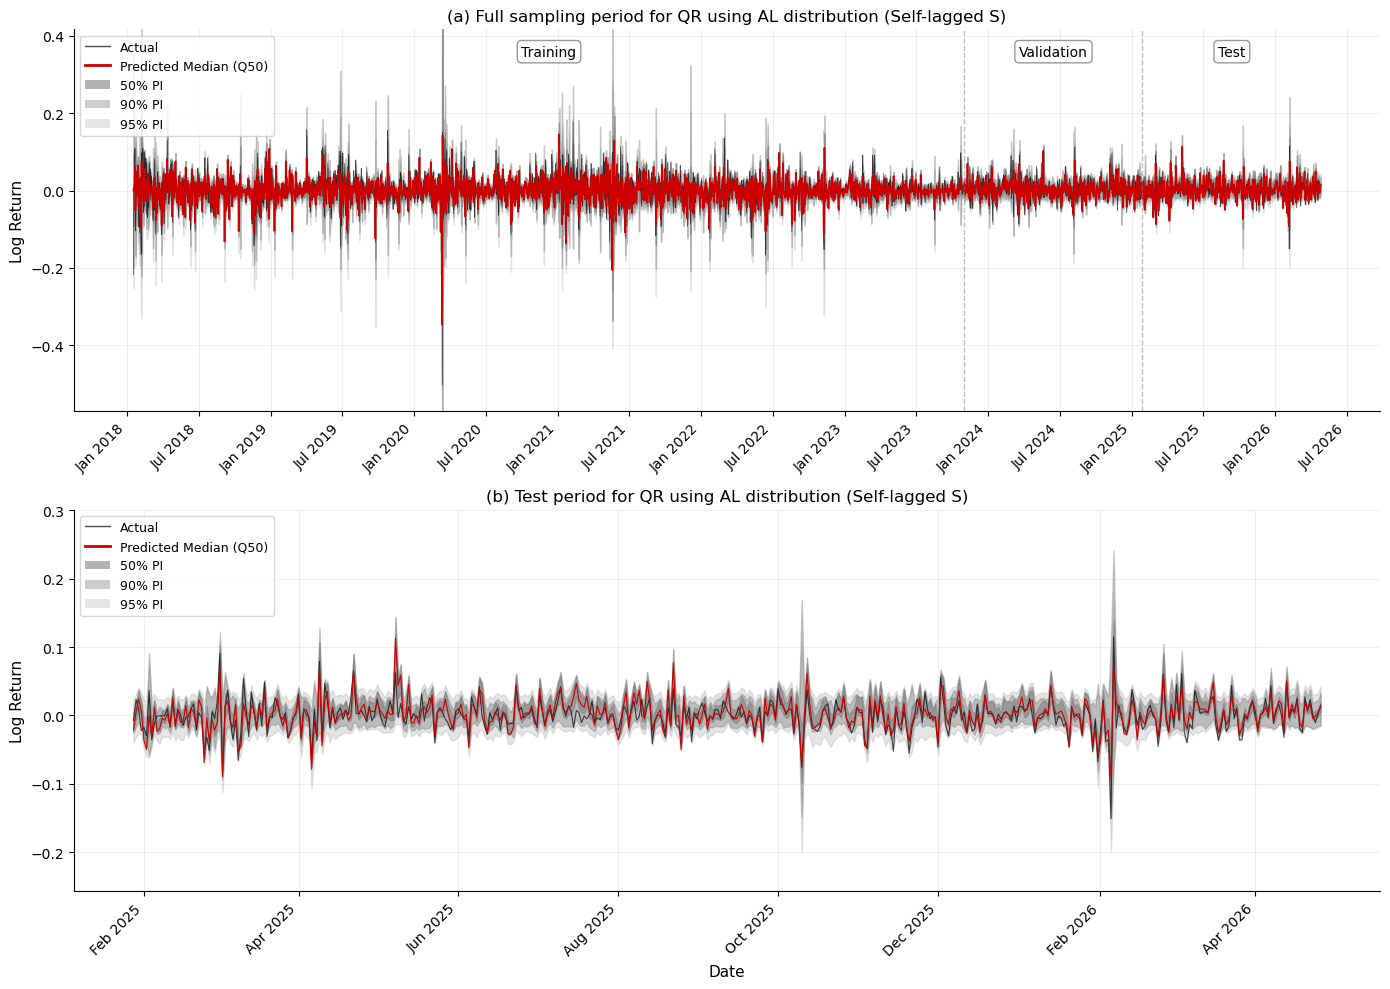


CROSSOVER ANALYSIS -- QRNN Self S (TEST PERIOD, T=454)
              Pair   Violations    Pct (%)
  ------------------------------------------
  (0.025, 0.050):           5      1.10% <-- TAIL
  (0.050, 0.250):          10      2.20%
  (0.250, 0.500):          32      7.05%
  (0.500, 0.750):           0      0.00%
  (0.750, 0.950):          64     14.10%
  (0.950, 0.975):          29      6.39% <-- TAIL
  ------------------------------------------
  Total violations:         140  (5.14% of all pairs)
  Tail violations:           34  (3.74% of tail pairs)


In [27]:
def train_final_model_qrnn(alpha, config, y_train, X_train, y_val, X_val, y_test, X_test):
    torch.manual_seed(2026)
    input_dim = X_train.shape[1]
    model = HybridQRNN(input_dim, config)

    if config['optimizer'] == 'adam':
        optimizer = torch.optim.Adam(model.parameters(), lr=config['lr'],
                                     weight_decay=config['weight_decay'])
    else:
        optimizer = torch.optim.AdamW(model.parameters(), lr=config['lr'],
                                      weight_decay=config['weight_decay'])

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=10, factor=0.5, min_lr=1e-6)

    best_val_loss    = float('inf')
    patience_counter = 0
    patience         = config.get('patience', 30)
    max_epochs       = 200
    best_model_state = None
    train_losses, val_losses = [], []

    for epoch in range(max_epochs):
        model.train()
        optimizer.zero_grad()
        q_hybrid, sigma = model(y_train, X_train)
        loss = hybrid_qrnn_loss(y_train, q_hybrid, sigma, alpha)

        if torch.isnan(loss) or torch.isinf(loss):
            print(f"  NaN/Inf at epoch {epoch}, stopping")
            break

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), config['gradient_clip'])
        optimizer.step()
        train_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            q_val, sigma_val = model(y_val, X_val)
            val_loss = hybrid_qrnn_loss(y_val, q_val, sigma_val, alpha)

        val_losses.append(val_loss.item())
        scheduler.step(val_loss)

        if (epoch + 1) % 50 == 0:
            print(f"  Epoch {epoch+1}: train={loss.item():.4f}, val={val_loss.item():.4f}")

        if val_loss < best_val_loss:
            best_val_loss    = val_loss.item()
            patience_counter = 0
            best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"  Early stopping at epoch {epoch+1}")
                break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    model.eval()
    with torch.no_grad():
        q_test, sigma_test = model(y_test, X_test)
        test_loss = hybrid_qrnn_loss(y_test, q_test, sigma_test, alpha)

        if alpha <= 0.5:
            coverage = (y_test <= q_test).float().mean().item()
        else:
            coverage = (y_test > q_test).float().mean().item()
        expected       = alpha if alpha <= 0.5 else 1 - alpha
        coverage_ratio = coverage / expected

    with torch.no_grad():
        est_beta1 = torch.sigmoid(model.beta1_raw).item()
        est_beta2 = torch.nn.functional.softplus(model.beta2_raw).item()
        est_psi   = torch.sigmoid(model.psi_raw).item()
        est_sigma = torch.nn.functional.softplus(model.sigma_raw).item()

    print(f"  Test loss: {test_loss.item():.4f} | Coverage ratio: {coverage_ratio:.3f} | "
          f"beta1={est_beta1:.4f} | beta2={est_beta2:.4f} | "
          f"psi={est_psi:.4f} | sigma={est_sigma:.4f}")

    history_df = pd.DataFrame({
        'epoch':      range(len(train_losses)),
        'train_loss': train_losses,
        'val_loss':   val_losses
    })
    history_df.to_csv(f'qrnn_self_history_alpha_{alpha}.csv', index=False)

    return model, train_losses, val_losses, q_test.numpy()


# -------------------------
# Convert test tensors
# -------------------------
X_test_q = torch.tensor(test_df[feature_cols].values, dtype=torch.float32)
y_test_q  = torch.tensor(test_df['log_return'].values, dtype=torch.float32)

# -------------------------
# Train all alpha levels
# -------------------------
alpha_levels = [0.025, 0.050, 0.250, 0.500, 0.750, 0.950, 0.975]
results_qrnn = {}

for alpha in alpha_levels:
    print(f"\n{'='*60}")
    print(f"Training final model for alpha = {alpha} (self-lagged)")
    print(f"{'='*60}")
    config = best_configs_qrnn[alpha]  # fixed -- was best_configs2
    model, train_losses, val_losses, q_test_pred = train_final_model_qrnn(
        alpha, config, y_train, X_train, y_val, X_val, y_test_q, X_test_q
    )
    results_qrnn[alpha] = {
        'model':        model,
        'train_losses': train_losses,
        'val_losses':   val_losses,
        'q_test':       q_test_pred
    }


# ============================================================
# Plotting
# ============================================================
import matplotlib.dates as mdates
from matplotlib.patches import Patch
from matplotlib.lines import Line2D


def plot_two_panel_qrnn(results_qrnn, train_df, val_df, test_df, feature_cols,
                        title_suffix='QR using AL distribution (Self-lagged S)',
                        save_fname='hybrid_qrnn_self_s_predictions.png'):

    actual_color = '#000000'
    pred_color   = '#CC0000'
    pi_color     = '#808080'

    all_preds = {}
    X_all = torch.tensor(df[feature_cols].values, dtype=torch.float32)
    y_all = torch.tensor(df['log_return'].values, dtype=torch.float32)

    alpha_levels = list(best_configs_qrnn.keys())

    for alpha in alpha_levels:
        model = results_qrnn[alpha]['model']
        model.eval()
        with torch.no_grad():
            q_all, _ = model(y_all, X_all)
            all_preds[alpha] = q_all.numpy()

    all_dates  = df.index
    train_size = len(train_df)
    val_size   = len(val_df)
    y_all_np   = df['log_return'].values

    have_95 = (0.025 in all_preds) and (0.975 in all_preds)
    have_90 = (0.05  in all_preds) and (0.95  in all_preds)
    have_50 = (0.25  in all_preds) and (0.75  in all_preds)

    fig, axes = plt.subplots(2, 1, figsize=(14, 10))

    # ---- Panel (a): Full period ----
    ax = axes[0]
    y_min, y_max = y_all_np.min(), y_all_np.max()
    y_range = y_max - y_min
    ax.set_ylim(y_min - 0.1 * y_range, y_max + 0.35 * y_range)

    ax.plot(all_dates, y_all_np, color=actual_color, linewidth=0.5, alpha=0.7, label='Actual')
    ax.plot(all_dates, all_preds[0.5], color=pred_color, linewidth=1.2, label='Predicted Median (Q50)')

    if have_95:
        ax.fill_between(all_dates, all_preds[0.025], all_preds[0.975], color=pi_color, alpha=0.2)
    if have_90:
        ax.fill_between(all_dates, all_preds[0.05],  all_preds[0.95],  color=pi_color, alpha=0.4)
    if have_50:
        ax.fill_between(all_dates, all_preds[0.25],  all_preds[0.75],  color=pi_color, alpha=0.6)

    ax.axvline(x=train_df.index[-1], color='gray', linestyle='--', alpha=0.5, linewidth=1)
    ax.axvline(x=val_df.index[-1],   color='gray', linestyle='--', alpha=0.5, linewidth=1)

    y_label = y_max + 0.25 * y_range
    ax.text(train_df.index[len(train_df)//2], y_label, 'Training',
            ha='center', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))
    ax.text(val_df.index[len(val_df)//2], y_label, 'Validation',
            ha='center', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))
    ax.text(test_df.index[len(test_df)//2], y_label, 'Test',
            ha='center', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))

    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

    legend_elements = [
        Line2D([0], [0], color=actual_color, lw=1, alpha=0.7, label='Actual'),
        Line2D([0], [0], color=pred_color,   lw=2,             label='Predicted Median (Q50)'),
    ]
    if have_50: legend_elements.append(Patch(facecolor=pi_color, alpha=0.6, label='50% PI'))
    if have_90: legend_elements.append(Patch(facecolor=pi_color, alpha=0.4, label='90% PI'))
    if have_95: legend_elements.append(Patch(facecolor=pi_color, alpha=0.2, label='95% PI'))

    ax.legend(handles=legend_elements, loc='upper left', fontsize=9)
    ax.set_title(f'(a) Full sampling period for {title_suffix}', fontsize=12)
    ax.set_ylabel('Log Return', fontsize=11)
    ax.grid(True, alpha=0.2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # ---- Panel (b): Test period ----
    ax2 = axes[1]
    test_dates = test_df.index
    y_test_np  = test_df['log_return'].values

    y_min_t, y_max_t = y_test_np.min(), y_test_np.max()
    y_range_t = y_max_t - y_min_t
    ax2.set_ylim(y_min_t - 0.4 * y_range_t, y_max_t + 0.7 * y_range_t)

    ax2.plot(test_dates, y_test_np, color=actual_color, linewidth=0.8, alpha=0.7, label='Actual')
    ax2.plot(test_dates, all_preds[0.5][train_size + val_size:],
             color=pred_color, linewidth=0.8)

    if have_95:
        ax2.fill_between(test_dates,
                         all_preds[0.025][train_size + val_size:],
                         all_preds[0.975][train_size + val_size:],
                         color=pi_color, alpha=0.2)
    if have_90:
        ax2.fill_between(test_dates,
                         all_preds[0.05][train_size + val_size:],
                         all_preds[0.95][train_size + val_size:],
                         color=pi_color, alpha=0.4)
    if have_50:
        ax2.fill_between(test_dates,
                         all_preds[0.25][train_size + val_size:],
                         all_preds[0.75][train_size + val_size:],
                         color=pi_color, alpha=0.6)

    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')

    ax2.legend(handles=legend_elements, loc='upper left', fontsize=9)
    ax2.set_title(f'(b) Test period for {title_suffix}', fontsize=12)
    ax2.set_xlabel('Date', fontsize=11)
    ax2.set_ylabel('Log Return', fontsize=11)
    ax2.grid(True, alpha=0.2)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.savefig(save_fname, dpi=300, bbox_inches='tight')
    print(f"Plot saved to {save_fname}")
    plt.show()

    return all_preds, train_size, val_size


# -------------------------
# Run plotting -- self-lagged S
# -------------------------
all_preds_qrnn, train_size, val_size = plot_two_panel_qrnn(
    results_qrnn, train_df, val_df, test_df, feature_cols,
    title_suffix='QR using AL distribution (Self-lagged S)',
    save_fname='hybrid_qrnn_self_s_predictions.png'
)


# ============================================================
# Crossover analysis -- test period, tail focused
# ============================================================
import numpy as np

def compute_crossovers(all_preds, levels, train_size, val_size, model_name='QRNN'):
    """
    Count crossover violations across adjacent levels on test period.
    Lower level should always be <= higher level.
    """
    preds = {lv: all_preds[lv][train_size + val_size:] for lv in levels}
    T = len(preds[levels[0]])

    adjacent_pairs = [
        (0.025, 0.050),
        (0.050, 0.250),
        (0.250, 0.500),
        (0.500, 0.750),
        (0.750, 0.950),
        (0.950, 0.975),
    ]

    tail_pairs = [(0.025, 0.050), (0.950, 0.975)]

    print(f"\n{'='*60}")
    print(f"CROSSOVER ANALYSIS -- {model_name} (TEST PERIOD, T={T})")
    print(f"{'='*60}")
    print(f"  {'Pair':>16} {'Violations':>12} {'Pct (%)':>10}")
    print(f"  {'-'*42}")

    total_violations = 0
    tail_violations  = 0

    for lo, hi in adjacent_pairs:
        violations = int(np.sum(preds[lo] > preds[hi]))
        pct        = violations / T * 100
        total_violations += violations
        marker = ' <-- TAIL' if (lo, hi) in tail_pairs else ''
        print(f"  ({lo:.3f}, {hi:.3f}):  {violations:>10}  {pct:>8.2f}%{marker}")
        if (lo, hi) in tail_pairs:
            tail_violations += violations

    print(f"  {'-'*42}")
    print(f"  Total violations:  {total_violations:>10}  "
          f"({total_violations / (T * len(adjacent_pairs)) * 100:.2f}% of all pairs)")
    print(f"  Tail violations:   {tail_violations:>10}  "
          f"({tail_violations / (T * 2) * 100:.2f}% of tail pairs)")

    return total_violations, tail_violations


total_viol, tail_viol = compute_crossovers(
    all_preds_qrnn, alpha_levels, train_size, val_size,
    model_name='QRNN Self S'
)

In [33]:
import numpy as np


def compute_hre(y_true, q_pred, alpha):
    """
    Hit Rate Error for quantile evaluation.
    HRE = |mean(1(q_hat > y)) - alpha|
    """
    y        = y_true.numpy() if hasattr(y_true, 'numpy') else np.array(y_true)
    q        = q_pred if isinstance(q_pred, np.ndarray) else np.array(q_pred)
    hit_rate = np.mean(q > y)
    hre      = np.abs(hit_rate - alpha)
    return hre


def compute_test_metrics_qrnn(results, alpha_levels, y_test, X_test, model_name='QRNN'):
    """
    Compute average NLL and HRE on test set across all alpha levels.
    """
    print(f"\n{'='*60}")
    print(f"TEST SET METRICS -- {model_name}")
    print(f"{'='*60}")
    print(f"  {'alpha':>6} {'NLL':>10} {'HRE':>14}")
    print(f"  {'-'*34}")

    nll_list = []
    hre_list = []

    for alpha in alpha_levels:
        model = results[alpha]['model']
        model.eval()

        with torch.no_grad():
            q_test, sigma_test = model(y_test, X_test)
            test_nll = hybrid_qrnn_loss(y_test, q_test, sigma_test, alpha).item()

        q_test_np = q_test.numpy()
        y_test_np = y_test.numpy()

        hre = compute_hre(y_test_np, q_test_np, alpha)

        nll_list.append(test_nll)
        hre_list.append(hre)

        print(f"  {alpha:>6} {test_nll:>10.4f} {hre:>14.6f}")

    print(f"  {'-'*34}")
    print(f"  {'Mean':>6} {np.mean(nll_list):>10.4f} {np.mean(hre_list):>14.6f}")
    print(f"\n  --> Average NLL: {np.mean(nll_list):.4f}")
    print(f"  --> Average HRE: {np.mean(hre_list):.6f}")

    return np.mean(nll_list), np.mean(hre_list)


# -------------------------
# Test tensors
# -------------------------
X_test_q = torch.tensor(test_df[feature_cols].values, dtype=torch.float32)
y_test_q  = torch.tensor(test_df['log_return'].values, dtype=torch.float32)

alpha_levels = [0.025, 0.050, 0.250, 0.500, 0.750, 0.950, 0.975]

# -------------------------
# Run metrics -- QRNN S self-lagged
# -------------------------
avg_nll_qrnn_s_self, avg_hre_qrnn_s_self = compute_test_metrics_qrnn(
    results_qrnn, alpha_levels, y_test_q, X_test_q,
    model_name='QRNN S Self-lagged'
)


TEST SET METRICS -- QRNN S Self-lagged
   alpha        NLL            HRE
  ----------------------------------
   0.025    -2.2535       0.005176
    0.05    -2.3925       0.029295
    0.25    -2.7295       0.080396
     0.5    -2.8186       0.092511
    0.75    -2.5777       0.166300
    0.95    -2.3522       0.027974
   0.975    -2.1174       0.025000
  ----------------------------------
    Mean    -2.4631       0.060950

  --> Average NLL: -2.4631
  --> Average HRE: 0.060950


In [29]:
import glob
import pandas as pd

def output_full_ranking(alpha_levels, prefix='qrnn_self_ranking'):
    """
    Load and display full ranking results for all alpha levels.
    prefix: file prefix used when saving
    """
    print("\n" + "="*80)
    print(f"FULL RANKING RESULTS -- {prefix.upper()}")
    print("="*80)

    all_ranking_dfs = []

    for alpha in alpha_levels:
        fname = f'{prefix}_alpha_{alpha}.csv'
        try:
            df_rank = pd.read_csv(fname)
            all_ranking_dfs.append(df_rank)

            print(f"\n{'='*80}")
            print(f"ALPHA = {alpha} -- Full Ranking ({len(df_rank)} trials)")
            print(f"{'='*80}")
            print(df_rank[['trial', 'nll', 'crp', 'crp_penalty',
                            'rank_nll', 'rank_crp', 'sum_rank',
                            'beta1', 'beta2', 'psi', 'sigma']].to_string(index=False))

            best = df_rank.iloc[0]
            print(f"\n  --> Best trial: #{int(best['trial'])} | "
                  f"NLL={best['nll']:.4f} | "
                  f"CRP={best['crp']:.4f} | "
                  f"sum_rank={int(best['sum_rank'])}")

        except FileNotFoundError:
            print(f"  WARNING: {fname} not found -- alpha={alpha} may not have finished")

    # save combined ranking across all levels
    if all_ranking_dfs:
        combined_df = pd.concat(all_ranking_dfs, ignore_index=True)
        combined_fname = f'{prefix}_all_alpha.csv'
        combined_df.to_csv(combined_fname, index=False)
        print(f"\nCombined ranking saved to {combined_fname}")

    # summary table -- best trial per alpha level
    print("\n" + "="*80)
    print(f"SUMMARY -- BEST TRIAL PER ALPHA LEVEL ({prefix.upper()})")
    print("="*80)
    print(f"  {'alpha':>6} {'trial':>6} {'nll':>8} {'crp':>8} {'crp_pen':>9} "
          f"{'sum_rank':>9} {'beta1':>8} {'beta2':>8} {'psi':>8} {'sigma':>8}")

    for alpha in alpha_levels:
        fname = f'{prefix}_alpha_{alpha}.csv'
        try:
            df_rank = pd.read_csv(fname)
            best = df_rank.iloc[0]
            print(f"  {alpha:>6} {int(best['trial']):>6} {best['nll']:>8.4f} "
                  f"{best['crp']:>8.4f} {best['crp_penalty']:>9.4f} "
                  f"{int(best['sum_rank']):>9} {best['beta1']:>8.4f} "
                  f"{best['beta2']:>8.4f} {best['psi']:>8.4f} "
                  f"{best['sigma']:>8.4f}")
        except FileNotFoundError:
            print(f"  {alpha:>6} -- file not found")


# -------------------------
# Run for QRNN self-lagged
# -------------------------
alpha_levels = [0.025, 0.050, 0.250, 0.500, 0.750, 0.950, 0.975]
output_full_ranking(alpha_levels, prefix='qrnn_self_ranking')


FULL RANKING RESULTS -- QRNN_SELF_RANKING

ALPHA = 0.025 -- Full Ranking (200 trials)
 trial       nll      crp  crp_penalty  rank_nll  rank_crp  sum_rank    beta1    beta2      psi    sigma
   185 -2.164549 0.971302     0.000824         3         9        12 0.288768 0.048626 0.935867 0.001499
   189 -2.192232 1.059603     0.003552         1        24        25 0.298034 0.045261 0.939467 0.001485
   187 -2.082920 0.971302     0.000824        19        10        29 0.281083 0.049461 0.943393 0.001539
   190 -2.130705 1.059603     0.003552         6        25        31 0.271650 0.043188 0.947701 0.001484
   119 -2.090072 1.059603     0.003552        16        17        33 0.294185 0.053448 0.916142 0.001726
   194 -2.119555 1.059603     0.003552         7        27        34 0.307406 0.051555 0.932869 0.001608
    98 -2.116747 0.883002     0.013688         8        32        40 0.336185 0.066782 0.909090 0.001692
   156 -2.142240 0.883002     0.013688         5        36        41 0.27

# Cross over dealing

In [36]:
import copy

import numpy as np
import optuna
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from optuna.samplers import TPESampler


# ============================================================
# Joint QRNN S Self-lagged
# One model jointly estimates all seven quantile levels
# ============================================================

alpha_levels = [0.025, 0.050, 0.250, 0.500, 0.750, 0.950, 0.975]
alpha_tensor = torch.tensor(alpha_levels, dtype=torch.float32)


class HybridQRNN_S_Self_Joint(nn.Module):
    def __init__(self, input_dim, config):
        super().__init__()

        self.n_levels = len(alpha_levels)
        self.eps = 1e-6

        # Seven level-specific parameter sets.
        # Initial values match the original single-level model.
        self.beta1_raw = nn.Parameter(torch.full((self.n_levels,), 1.386))
        self.beta2_raw = nn.Parameter(torch.full((self.n_levels,), 0.3))
        self.psi_raw   = nn.Parameter(torch.zeros(self.n_levels))
        self.sigma_raw = nn.Parameter(torch.full((self.n_levels,), 0.5))

        # Shared FNN
        layers = []
        prev_dim = input_dim
        n_hidden = config['n_hidden_layers']

        for i in range(n_hidden):
            hidden_dim = config[f'hidden_dim_{i}']
            layers.append(nn.Linear(prev_dim, hidden_dim))

            if config['layernorm']:
                layers.append(nn.LayerNorm(hidden_dim))

            layers.append(self._get_activation(config['activation']))

            if config['dropout'] > 0:
                layers.append(nn.Dropout(config['dropout']))

            prev_dim = hidden_dim

        # Output:
        # [median, delta12_raw, delta23_raw, delta34_raw,
        #          delta45_raw, delta56_raw, delta67_raw]
        layers.append(nn.Linear(prev_dim, self.n_levels))
        self.fnn = nn.Sequential(*layers)

        for m in self.fnn.modules():
            if isinstance(m, nn.Linear):
                if config['weight_init'] == 'glorot':
                    nn.init.xavier_uniform_(m.weight)
                elif config['weight_init'] == 'he':
                    nn.init.kaiming_uniform_(m.weight)

                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def _get_activation(self, name):
        return {
            'relu': nn.ReLU(),
            'elu':  nn.ELU(),
            'gelu': nn.GELU(),
            'tanh': nn.Tanh()
        }.get(name, nn.ReLU())

    def reconstruct_fnn_quantiles(self, raw_fnn):
        """
        raw_fnn shape: (T, 7)

        The first output is the median.
        The remaining six outputs become positive adjacent spacings.
        """
        median = raw_fnn[:, 0]
        delta  = F.softplus(raw_fnn[:, 1:]) + self.eps

        f4 = median

        f3 = f4 - delta[:, 2]
        f2 = f3 - delta[:, 1]
        f1 = f2 - delta[:, 0]

        f5 = f4 + delta[:, 3]
        f6 = f5 + delta[:, 4]
        f7 = f6 + delta[:, 5]

        fnn_quantiles = torch.stack(
            [f1, f2, f3, f4, f5, f6, f7],
            dim=1
        )

        return fnn_quantiles

    def forward(self, y, X, initial_caviar=None, initial_y=None):
        beta1 = torch.sigmoid(self.beta1_raw)
        beta2 = F.softplus(self.beta2_raw)
        psi   = torch.sigmoid(self.psi_raw)
        sigma = F.softplus(self.sigma_raw) + self.eps

        # One shared FNN pass gives all seven neural quantiles.
        raw_fnn       = self.fnn(X)
        fnn_quantiles = self.reconstruct_fnn_quantiles(raw_fnn)

        q_hybrid, q_caviar = compute_hybrid_location_self_s_joint(
            y=y,
            fnn_quantiles=fnn_quantiles,
            beta1=beta1,
            beta2=beta2,
            psi=psi,
            initial_caviar=initial_caviar,
            initial_y=initial_y
        )

        return q_hybrid, sigma, q_caviar, fnn_quantiles


def compute_hybrid_location_self_s_joint(
    y,
    fnn_quantiles,
    beta1,
    beta2,
    psi,
    initial_caviar=None,
    initial_y=None
):
    """
    Joint self-lagged Hybrid QRNN location -- S form.

    The pure CaViaR component uses its own previous output:

        q^S_{k,t}
        = beta1_k q^S_{k,t-1}
        + beta2_k |y_{t-1}|

    The final hybrid output is:

        q^H_{k,t}
        = psi_k q^S_{k,t}
        + (1-psi_k) f_{k,t}

    All seven levels are updated together at each time step.
    """
    T        = len(y)
    n_levels = fnn_quantiles.shape[1]
    zero_row = y.new_zeros(n_levels)

    q_caviar_list = []
    q_hybrid_list = []

    has_initial_state = (
        initial_caviar is not None and
        initial_y is not None
    )

    if (initial_caviar is None) != (initial_y is None):
        raise ValueError(
            "initial_caviar and initial_y must be supplied together."
        )

    previous_caviar = (
        initial_caviar if has_initial_state else zero_row
    )

    for t in range(T):

        # Training sample has no preceding state for t=0.
        # This initial row is excluded from the training loss.
        if t == 0 and not has_initial_state:
            q_caviar_list.append(zero_row)
            q_hybrid_list.append(zero_row)
            continue

        previous_y = initial_y if t == 0 else y[t-1]

        abs_y = torch.abs(previous_y)

        caviar_t = (
            beta1 * previous_caviar
            + beta2 * abs_y
        )

        hybrid_t = (
            psi * caviar_t
            + (1 - psi) * fnn_quantiles[t]
        )

        q_caviar_list.append(caviar_t)
        q_hybrid_list.append(hybrid_t)

        # Self-lagged: next step uses previous pure CaViaR output.
        previous_caviar = caviar_t

    q_caviar = torch.stack(q_caviar_list, dim=0)
    q_hybrid = torch.stack(q_hybrid_list, dim=0)

    return q_hybrid, q_caviar


# ============================================================
# Joint ALD NLL, HRE and crossover diagnostic
# ============================================================

def hybrid_qrnn_joint_loss(
    y,
    q_hybrid,
    sigma_al,
    alpha_values=alpha_levels
):
    """
    Joint Hybrid QRNN ALD NLL.

    y        : shape (T,)
    q_hybrid : shape (T, 7)
    sigma_al : shape (7,)

    Returns the average NLL across time and all seven levels.
    """
    alpha = torch.tensor(
        alpha_values,
        dtype=q_hybrid.dtype,
        device=q_hybrid.device
    )

    u         = y.unsqueeze(1) - q_hybrid
    indicator = (u < 0).float()
    rho_alpha = u * (alpha.unsqueeze(0) - indicator)

    nll = (
        -torch.log(alpha * (1 - alpha)).unsqueeze(0)
        + torch.log(sigma_al).unsqueeze(0)
        + rho_alpha / sigma_al.unsqueeze(0)
    )

    return nll.mean()


def compute_hre_joint(
    y,
    q_hybrid,
    alpha_values=alpha_levels
):
    """
    HRE_k = | empirical coverage_k - alpha_k |

    Returns:
        hre_by_level : shape (7,)
        mean_hre     : scalar
    """
    alpha = torch.tensor(
        alpha_values,
        dtype=q_hybrid.dtype,
        device=q_hybrid.device
    )

    empirical_coverage = (
        y.unsqueeze(1) <= q_hybrid
    ).float().mean(dim=0)

    hre_by_level = torch.abs(empirical_coverage - alpha)
    mean_hre     = hre_by_level.mean()

    return hre_by_level, mean_hre


def compute_crossover_joint(q_hybrid):
    """
    Crossover is a diagnostic only.
    It is not added to the training loss.
    """
    violations = q_hybrid[:, :-1] > q_hybrid[:, 1:]

    pair_counts = violations.sum(dim=0)
    T           = q_hybrid.shape[0]

    total_count = int(pair_counts.sum().item())
    total_rate  = total_count / (T * 6)

    tail_count = int(
        pair_counts[0].item() +
        pair_counts[-1].item()
    )
    tail_rate = tail_count / (T * 2)

    return {
        'pair_counts': [
            int(x) for x in pair_counts.tolist()
        ],
        'total_count': total_count,
        'total_rate':  total_rate,
        'tail_count':  tail_count,
        'tail_rate':   tail_rate
    }


# ============================================================
# Model fitting used inside each Optuna trial
# ============================================================

def fit_joint_qrnn_s_self(
    config,
    max_epochs=200,
    seed=2026
):
    torch.manual_seed(seed)

    model = HybridQRNN_S_Self_Joint(
        input_dim=X_train.shape[1],
        config=config
    )

    if config['optimizer'] == 'adam':
        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=config['lr'],
            weight_decay=config['weight_decay']
        )
    else:
        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=config['lr'],
            weight_decay=config['weight_decay']
        )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        patience=10,
        factor=0.5,
        min_lr=1e-6
    )

    best_val_loss    = float('inf')
    patience_counter = 0
    best_model_state = None

    for epoch in range(max_epochs):
        model.train()
        optimizer.zero_grad()

        q_train, sigma_train, _, _ = model(
            y_train,
            X_train
        )

        # Exclude t=0 because it is only an initialisation row.
        train_loss = hybrid_qrnn_joint_loss(
            y_train[1:],
            q_train[1:],
            sigma_train
        )

        if torch.isnan(train_loss) or torch.isinf(train_loss):
            return None

        train_loss.backward()

        nn.utils.clip_grad_norm_(
            model.parameters(),
            config['gradient_clip']
        )

        optimizer.step()

        # Validation continues from the final training state.
        model.eval()
        with torch.no_grad():
            _, sigma_val, q_caviar_train, _ = model(
                y_train,
                X_train
            )

            q_val, _, _, _ = model(
                y_val,
                X_val,
                initial_caviar=q_caviar_train[-1],
                initial_y=y_train[-1]
            )

            val_loss = hybrid_qrnn_joint_loss(
                y_val,
                q_val,
                sigma_val
            )

        scheduler.step(val_loss.item())

        if val_loss.item() < best_val_loss:
            best_val_loss    = val_loss.item()
            patience_counter = 0
            best_model_state = copy.deepcopy(
                model.state_dict()
            )
        else:
            patience_counter += 1

            if patience_counter >= config['patience']:
                break

    if best_model_state is None:
        return None

    model.load_state_dict(best_model_state)
    return model


def evaluate_joint_qrnn_s_self(model):
    model.eval()

    with torch.no_grad():
        _, sigma_val, q_caviar_train, _ = model(
            y_train,
            X_train
        )

        q_val, _, _, fnn_val = model(
            y_val,
            X_val,
            initial_caviar=q_caviar_train[-1],
            initial_y=y_train[-1]
        )

        mean_nll = hybrid_qrnn_joint_loss(
            y_val,
            q_val,
            sigma_val
        ).item()

        hre_levels, mean_hre = compute_hre_joint(
            y_val,
            q_val
        )

        final_crossover = compute_crossover_joint(q_val)
        fnn_crossover   = compute_crossover_joint(fnn_val)

        beta1 = torch.sigmoid(model.beta1_raw)
        beta2 = F.softplus(model.beta2_raw)
        psi   = torch.sigmoid(model.psi_raw)
        sigma = F.softplus(model.sigma_raw) + model.eps

    return {
        'mean_nll':         mean_nll,
        'hre_by_level':     hre_levels.tolist(),
        'mean_hre':         mean_hre.item(),
        'final_crossover':  final_crossover,
        'fnn_crossover':    fnn_crossover,
        'beta1':            beta1.tolist(),
        'beta2':            beta2.tolist(),
        'psi':              psi.tolist(),
        'sigma':            sigma.tolist()
    }


# ============================================================
# Optuna objective
# ============================================================

def objective_qrnn_s_self_joint(trial):
    config = {
        'n_hidden_layers': trial.suggest_int(
            'n_hidden_layers', 1, 3
        ),
        'activation': trial.suggest_categorical(
            'activation',
            ['relu', 'elu', 'gelu', 'tanh']
        ),
        'dropout': trial.suggest_float(
            'dropout', 0.0, 0.5
        ),
        'layernorm': trial.suggest_categorical(
            'layernorm', [True, False]
        ),
        'weight_init': trial.suggest_categorical(
            'weight_init', ['glorot', 'he']
        ),
        'lr': trial.suggest_float(
            'lr', 1e-4, 5e-2, log=True
        ),
        'optimizer': trial.suggest_categorical(
            'optimizer', ['adam', 'adamw']
        ),
        'weight_decay': trial.suggest_float(
            'weight_decay', 0.0, 1e-4
        ),
        'gradient_clip': trial.suggest_categorical(
            'gradient_clip', [0.1, 1.0, 5.0]
        ),
        'patience': trial.suggest_categorical(
            'patience', [10, 20, 30]
        )
    }

    for i in range(config['n_hidden_layers']):
        config[f'hidden_dim_{i}'] = trial.suggest_int(
            f'hidden_dim_{i}',
            32,
            256
        )

    model = fit_joint_qrnn_s_self(
        config=config,
        max_epochs=200,
        seed=2026
    )

    if model is None:
        return float('inf')

    metrics = evaluate_joint_qrnn_s_self(model)

    trial.set_user_attr(
        'mean_nll',
        metrics['mean_nll']
    )
    trial.set_user_attr(
        'mean_hre',
        metrics['mean_hre']
    )
    trial.set_user_attr(
        'hre_by_level',
        metrics['hre_by_level']
    )

    trial.set_user_attr(
        'final_crossover_count',
        metrics['final_crossover']['total_count']
    )
    trial.set_user_attr(
        'final_crossover_rate',
        metrics['final_crossover']['total_rate']
    )
    trial.set_user_attr(
        'tail_crossover_count',
        metrics['final_crossover']['tail_count']
    )
    trial.set_user_attr(
        'tail_crossover_rate',
        metrics['final_crossover']['tail_rate']
    )
    trial.set_user_attr(
        'pair_crossover_counts',
        metrics['final_crossover']['pair_counts']
    )
    trial.set_user_attr(
        'fnn_crossover_count',
        metrics['fnn_crossover']['total_count']
    )

    trial.set_user_attr('beta1', metrics['beta1'])
    trial.set_user_attr('beta2', metrics['beta2'])
    trial.set_user_attr('psi',   metrics['psi'])
    trial.set_user_attr('sigma', metrics['sigma'])

    print(
        f"Trial {trial.number}: "
        f"Mean NLL={metrics['mean_nll']:.6f} | "
        f"Mean HRE={metrics['mean_hre']:.6f} | "
        f"Final crossover="
        f"{metrics['final_crossover']['total_rate']:.2%} | "
        f"FNN crossover="
        f"{metrics['fnn_crossover']['total_rate']:.2%}"
    )

    # Optuna requires one scalar objective.
    # Final model selection below uses NLL rank + HRE rank.
    return metrics['mean_nll']


# ============================================================
# Rank trials using Mean NLL rank + Mean HRE rank
# ============================================================

def select_best_trial_by_rank_joint(study):
    trials = [
        t for t in study.trials
        if t.state == optuna.trial.TrialState.COMPLETE
        and t.value is not None
        and np.isfinite(t.value)
        and 'mean_nll' in t.user_attrs
        and 'mean_hre' in t.user_attrs
    ]

    if len(trials) == 0:
        raise RuntimeError(
            "No valid completed Optuna trials."
        )

    for t in trials:
        t._nll = t.user_attrs['mean_nll']
        t._hre = t.user_attrs['mean_hre']

    for rank, t in enumerate(
        sorted(trials, key=lambda x: x._nll),
        start=1
    ):
        t._rank_nll = rank

    for rank, t in enumerate(
        sorted(trials, key=lambda x: x._hre),
        start=1
    ):
        t._rank_hre = rank

    best = min(
        trials,
        key=lambda t: (
            t._rank_nll + t._rank_hre,
            t._nll,
            t._hre,
            t.number
        )
    )

    return best, trials


# ============================================================
# Run one joint Optuna study for all seven levels
# ============================================================

base_seed = 2026

print("\n" + "=" * 70)
print("Tuning Joint QRNN S Self-lagged for all seven alpha levels")
print("=" * 70)

sampler = TPESampler(seed=base_seed)
study   = optuna.create_study(
    direction='minimize',
    sampler=sampler
)

study.optimize(
    objective_qrnn_s_self_joint,
    n_trials=800,
    show_progress_bar=True
)

best_trial, all_trials = select_best_trial_by_rank_joint(
    study
)


# ============================================================
# Save full trial ranking
# ============================================================

ranking_records = []

for t in all_trials:
    record = {
        'trial':                  t.number,
        'mean_nll':               t._nll,
        'mean_hre':               t._hre,
        'rank_nll':               t._rank_nll,
        'rank_hre':               t._rank_hre,
        'sum_rank':               t._rank_nll + t._rank_hre,
        'final_crossover_count':  t.user_attrs[
            'final_crossover_count'
        ],
        'final_crossover_rate':   t.user_attrs[
            'final_crossover_rate'
        ],
        'tail_crossover_count':   t.user_attrs[
            'tail_crossover_count'
        ],
        'tail_crossover_rate':    t.user_attrs[
            'tail_crossover_rate'
        ],
        'fnn_crossover_count':    t.user_attrs[
            'fnn_crossover_count'
        ]
    }

    for k, alpha in enumerate(alpha_levels):
        suffix = f'alpha_{alpha}'

        record[f'hre_{suffix}'] = (
            t.user_attrs['hre_by_level'][k]
        )
        record[f'beta1_{suffix}'] = (
            t.user_attrs['beta1'][k]
        )
        record[f'beta2_{suffix}'] = (
            t.user_attrs['beta2'][k]
        )
        record[f'psi_{suffix}'] = (
            t.user_attrs['psi'][k]
        )
        record[f'sigma_{suffix}'] = (
            t.user_attrs['sigma'][k]
        )

    record.update(t.params)
    ranking_records.append(record)


ranking_df = pd.DataFrame(ranking_records)
ranking_df = ranking_df.sort_values(
    ['sum_rank', 'mean_nll', 'mean_hre']
)

ranking_df.to_csv(
    'joint_qrnn_s_self_ranking.csv',
    index=False
)


# ============================================================
# Refit the selected configuration
# ============================================================

best_config_s_self = best_trial.params.copy()

best_model_s_self_joint = fit_joint_qrnn_s_self(
    config=best_config_s_self,
    max_epochs=200,
    seed=2026
)

best_metrics_s_self_joint = evaluate_joint_qrnn_s_self(
    best_model_s_self_joint
)


# Save selected model
torch.save(
    {
        'model_state_dict': best_model_s_self_joint.state_dict(),
        'config':           best_config_s_self,
        'alpha_levels':     alpha_levels,
        'validation_metrics': best_metrics_s_self_joint
    },
    'joint_qrnn_s_self_best.pt'
)


# ============================================================
# Final summary
# ============================================================

print("\n" + "=" * 70)
print("TUNING COMPLETE -- JOINT QRNN S SELF-LAGGED")
print("=" * 70)

print(f"Best trial: #{best_trial.number}")
print(
    f"NLL rank: {best_trial._rank_nll} | "
    f"HRE rank: {best_trial._rank_hre} | "
    f"Sum rank: "
    f"{best_trial._rank_nll + best_trial._rank_hre}"
)

print(
    f"Mean validation NLL: "
    f"{best_metrics_s_self_joint['mean_nll']:.6f}"
)
print(
    f"Mean validation HRE: "
    f"{best_metrics_s_self_joint['mean_hre']:.6f}"
)

print("\nHRE by alpha:")
for alpha, hre in zip(
    alpha_levels,
    best_metrics_s_self_joint['hre_by_level']
):
    print(f"  alpha={alpha:.3f}: HRE={hre:.6f}")

print(
    "\nFinal hybrid crossover: "
    f"{best_metrics_s_self_joint['final_crossover']['total_count']} "
    f"({best_metrics_s_self_joint['final_crossover']['total_rate']:.2%})"
)

print(
    "Tail crossover: "
    f"{best_metrics_s_self_joint['final_crossover']['tail_count']} "
    f"({best_metrics_s_self_joint['final_crossover']['tail_rate']:.2%})"
)

print(
    "FNN crossover count: "
    f"{best_metrics_s_self_joint['fnn_crossover']['total_count']}"
)

print("\nEstimated parameters by level:")
for k, alpha in enumerate(alpha_levels):
    print(
        f"  alpha={alpha:.3f} | "
        f"beta1={best_metrics_s_self_joint['beta1'][k]:.4f} | "
        f"beta2={best_metrics_s_self_joint['beta2'][k]:.4f} | "
        f"psi={best_metrics_s_self_joint['psi'][k]:.4f} | "
        f"sigma={best_metrics_s_self_joint['sigma'][k]:.4f}"
    )

print(f"\nBest hyperparameters: {best_config_s_self}")
print(
    "Full ranking saved to: "
    "joint_qrnn_s_self_ranking.csv"
)
print(
    "Best model saved to: "
    "joint_qrnn_s_self_best.pt"
)

[I 2026-07-28 14:27:16,434] A new study created in memory with name: no-name-6a9741af-642e-4811-b37a-dd95796b5e85



Tuning Joint QRNN S Self-lagged for all seven alpha levels


  0%|          | 0/800 [00:00<?, ?it/s]

Trial 0: Mean NLL=2.511040 | Mean HRE=0.102633 | Final crossover=0.00% | FNN crossover=0.00%
[I 2026-07-28 14:27:36,463] Trial 0 finished with value: 2.5110397338867188 and parameters: {'n_hidden_layers': 1, 'activation': 'elu', 'dropout': 0.49377524711883497, 'layernorm': False, 'weight_init': 'he', 'lr': 0.0006552020421842752, 'optimizer': 'adam', 'weight_decay': 8.940884610144999e-05, 'gradient_clip': 5.0, 'patience': 30, 'hidden_dim_0': 38}. Best is trial 0 with value: 2.5110397338867188.
Trial 1: Mean NLL=1.474749 | Mean HRE=0.103280 | Final crossover=0.00% | FNN crossover=0.00%
[I 2026-07-28 14:27:54,031] Trial 1 finished with value: 1.4747486114501953 and parameters: {'n_hidden_layers': 1, 'activation': 'tanh', 'dropout': 0.07458356653667625, 'layernorm': False, 'weight_init': 'he', 'lr': 0.006969178688110181, 'optimizer': 'adam', 'weight_decay': 2.574006001095316e-05, 'gradient_clip': 1.0, 'patience': 30, 'hidden_dim_0': 102}. Best is trial 1 with value: 1.4747486114501953.
Tri

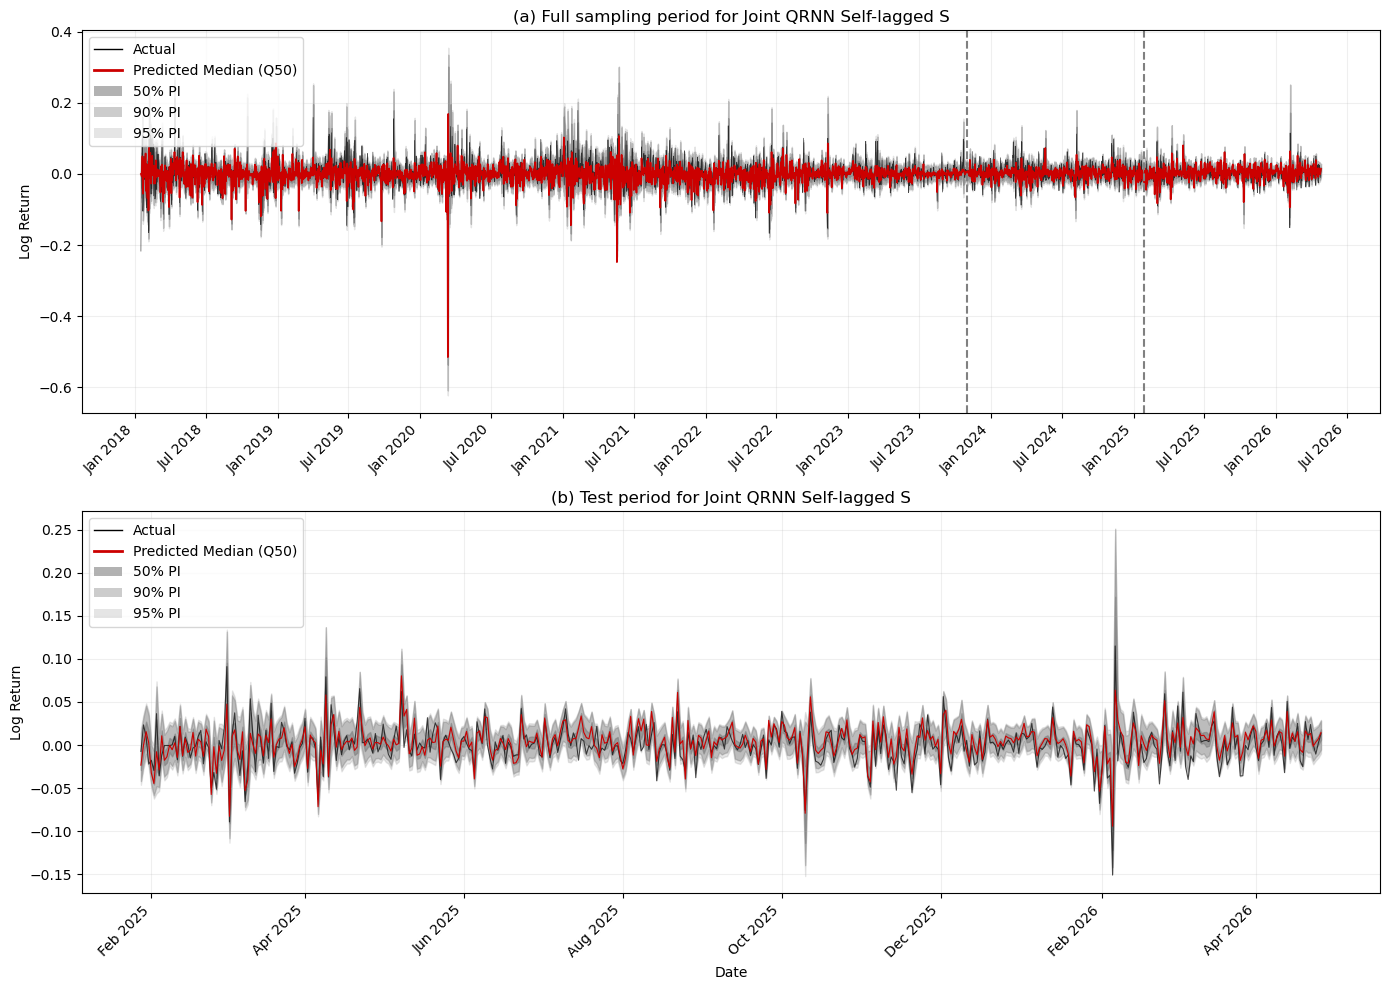

Plot saved to hybrid_qrnn_self_s_joint_predictions.png

TEST METRICS -- JOINT QRNN S SELF-LAGGED
 alpha       NLL  Hit_Rate      HRE
 0.025 -2.458386  0.033040 0.008040
 0.050 -2.528619  0.096916 0.046916
 0.250 -2.701026  0.411894 0.161894
 0.500 -2.748550  0.674009 0.174009
 0.750 -2.771369  0.819383 0.069383
 0.950 -2.480892  0.991189 0.041189
 0.975 -2.404257  0.995595 0.020595

Average NLL: -2.584728
Average HRE: 0.074575

CROSSOVER ANALYSIS -- FINAL HYBRID OUTPUT
(0.025, 0.050): 0 (0.00%) <-- TAIL
(0.050, 0.250): 0 (0.00%)
(0.250, 0.500): 8 (1.76%)
(0.500, 0.750): 15 (3.30%)
(0.750, 0.950): 0 (0.00%)
(0.950, 0.975): 14 (3.08%) <-- TAIL

Total violations: 37 (1.36%)
Tail violations: 14 (1.54%)

CROSSOVER ANALYSIS -- MONOTONIC FNN OUTPUT
(0.025, 0.050): 0 (0.00%) <-- TAIL
(0.050, 0.250): 0 (0.00%)
(0.250, 0.500): 0 (0.00%)
(0.500, 0.750): 0 (0.00%)
(0.750, 0.950): 0 (0.00%)
(0.950, 0.975): 0 (0.00%) <-- TAIL

Total violations: 0 (0.00%)
Tail violations: 0 (0.00%)


In [38]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from matplotlib.patches import Patch
from matplotlib.lines import Line2D


# ============================================================
# Joint QRNN S Self-lagged -- plotting and test evaluation
# Run directly after the joint tuning code
# ============================================================

X_test_q = torch.tensor(
    test_df[feature_cols].values,
    dtype=torch.float32
)
y_test_q = torch.tensor(
    test_df['log_return'].values,
    dtype=torch.float32
)

model = best_model_s_self_joint
model.eval()


# -------------------------
# Sequential predictions
# -------------------------
with torch.no_grad():
    q_train, sigma, caviar_train, fnn_train = model(
        y_train, X_train
    )

    q_val, _, caviar_val, fnn_val = model(
        y_val,
        X_val,
        initial_caviar=caviar_train[-1],
        initial_y=y_train[-1]
    )

    q_test, _, _, fnn_test = model(
        y_test_q,
        X_test_q,
        initial_caviar=caviar_val[-1],
        initial_y=y_val[-1]
    )

q_train_np = q_train.numpy()
q_val_np   = q_val.numpy()
q_test_np  = q_test.numpy()

q_all = np.concatenate(
    [q_train_np, q_val_np, q_test_np],
    axis=0
)

y_all = np.concatenate([
    train_df['log_return'].values,
    val_df['log_return'].values,
    test_df['log_return'].values
])

all_dates = (
    train_df.index
    .append(val_df.index)
    .append(test_df.index)
)

level_index = {
    alpha: k
    for k, alpha in enumerate(alpha_levels)
}

all_preds_qrnn_s_self = {
    alpha: q_all[:, k]
    for k, alpha in enumerate(alpha_levels)
}


# ============================================================
# Plotting
# ============================================================
def plot_two_panel_qrnn_joint(
    all_preds,
    train_df,
    val_df,
    test_df,
    save_fname='hybrid_qrnn_self_s_joint_predictions.png'
):
    actual_color = '#000000'
    pred_color   = '#CC0000'
    pi_color     = '#808080'

    train_size = len(train_df)
    val_size   = len(val_df)
    test_start = train_size + val_size

    test_dates = test_df.index
    y_test_np  = test_df['log_return'].values

    legend_elements = [
        Line2D(
            [0], [0],
            color=actual_color,
            lw=1,
            label='Actual'
        ),
        Line2D(
            [0], [0],
            color=pred_color,
            lw=2,
            label='Predicted Median (Q50)'
        ),
        Patch(
            facecolor=pi_color,
            alpha=0.6,
            label='50% PI'
        ),
        Patch(
            facecolor=pi_color,
            alpha=0.4,
            label='90% PI'
        ),
        Patch(
            facecolor=pi_color,
            alpha=0.2,
            label='95% PI'
        )
    ]

    fig, axes = plt.subplots(
        2, 1, figsize=(14, 10)
    )

    # -------------------------
    # Full sample
    # -------------------------
    ax = axes[0]

    ax.plot(
        all_dates,
        y_all,
        color=actual_color,
        linewidth=0.5,
        alpha=0.7
    )
    ax.plot(
        all_dates,
        all_preds[0.500],
        color=pred_color,
        linewidth=1.2
    )
    ax.fill_between(
        all_dates,
        all_preds[0.025],
        all_preds[0.975],
        color=pi_color,
        alpha=0.2
    )
    ax.fill_between(
        all_dates,
        all_preds[0.050],
        all_preds[0.950],
        color=pi_color,
        alpha=0.4
    )
    ax.fill_between(
        all_dates,
        all_preds[0.250],
        all_preds[0.750],
        color=pi_color,
        alpha=0.6
    )

    ax.axvline(
        train_df.index[-1],
        color='gray',
        linestyle='--'
    )
    ax.axvline(
        val_df.index[-1],
        color='gray',
        linestyle='--'
    )

    ax.xaxis.set_major_formatter(
        mdates.DateFormatter('%b %Y')
    )
    ax.xaxis.set_major_locator(
        mdates.MonthLocator(interval=6)
    )
    plt.setp(
        ax.xaxis.get_majorticklabels(),
        rotation=45,
        ha='right'
    )

    ax.set_title(
        '(a) Full sampling period for '
        'Joint QRNN Self-lagged S'
    )
    ax.set_ylabel('Log Return')
    ax.legend(
        handles=legend_elements,
        loc='upper left'
    )
    ax.grid(True, alpha=0.2)

    # -------------------------
    # Test sample
    # -------------------------
    ax2 = axes[1]

    ax2.plot(
        test_dates,
        y_test_np,
        color=actual_color,
        linewidth=0.8,
        alpha=0.7
    )
    ax2.plot(
        test_dates,
        all_preds[0.500][test_start:],
        color=pred_color,
        linewidth=0.8
    )
    ax2.fill_between(
        test_dates,
        all_preds[0.025][test_start:],
        all_preds[0.975][test_start:],
        color=pi_color,
        alpha=0.2
    )
    ax2.fill_between(
        test_dates,
        all_preds[0.050][test_start:],
        all_preds[0.950][test_start:],
        color=pi_color,
        alpha=0.4
    )
    ax2.fill_between(
        test_dates,
        all_preds[0.250][test_start:],
        all_preds[0.750][test_start:],
        color=pi_color,
        alpha=0.6
    )

    ax2.xaxis.set_major_formatter(
        mdates.DateFormatter('%b %Y')
    )
    ax2.xaxis.set_major_locator(
        mdates.MonthLocator(interval=2)
    )
    plt.setp(
        ax2.xaxis.get_majorticklabels(),
        rotation=45,
        ha='right'
    )

    ax2.set_title(
        '(b) Test period for '
        'Joint QRNN Self-lagged S'
    )
    ax2.set_xlabel('Date')
    ax2.set_ylabel('Log Return')
    ax2.legend(
        handles=legend_elements,
        loc='upper left'
    )
    ax2.grid(True, alpha=0.2)

    plt.tight_layout()
    plt.savefig(
        save_fname,
        dpi=300,
        bbox_inches='tight'
    )
    plt.show()

    print(f'Plot saved to {save_fname}')


plot_two_panel_qrnn_joint(
    all_preds_qrnn_s_self,
    train_df,
    val_df,
    test_df
)


# ============================================================
# Test NLL and HRE
# ============================================================
def compute_test_metrics_joint(
    y_test,
    q_test,
    sigma,
    alpha_levels
):
    records = []

    for k, alpha in enumerate(alpha_levels):
        y = y_test
        q = q_test[:, k]
        sigma_k = sigma[k]

        u = y - q
        indicator = (u < 0).float()
        rho = u * (alpha - indicator)

        nll = (
            -np.log(alpha * (1 - alpha))
            + torch.log(sigma_k)
            + rho / sigma_k
        ).mean().item()

        hit_rate = (
            y <= q
        ).float().mean().item()

        hre = abs(hit_rate - alpha)

        records.append({
            'alpha': alpha,
            'NLL': nll,
            'Hit_Rate': hit_rate,
            'HRE': hre
        })

    results = pd.DataFrame(records)

    print('\n' + '=' * 60)
    print('TEST METRICS -- JOINT QRNN S SELF-LAGGED')
    print('=' * 60)
    print(results.to_string(index=False))
    print(f"\nAverage NLL: {results['NLL'].mean():.6f}")
    print(f"Average HRE: {results['HRE'].mean():.6f}")

    results.to_csv(
        'joint_qrnn_s_self_test_metrics.csv',
        index=False
    )

    return results


test_metrics_qrnn_s_self = compute_test_metrics_joint(
    y_test_q,
    q_test,
    sigma,
    alpha_levels
)


# ============================================================
# Test crossover analysis
# ============================================================
def compute_crossovers_joint(
    q_pred,
    levels,
    model_name
):
    q = q_pred.numpy()
    T = len(q)

    total_violations = 0
    tail_violations  = 0

    print('\n' + '=' * 60)
    print(f'CROSSOVER ANALYSIS -- {model_name}')
    print('=' * 60)

    for k in range(len(levels) - 1):
        lo = levels[k]
        hi = levels[k + 1]

        violations = int(
            np.sum(q[:, k] > q[:, k + 1])
        )
        percentage = violations / T * 100

        total_violations += violations

        if k == 0 or k == len(levels) - 2:
            tail_violations += violations
            marker = ' <-- TAIL'
        else:
            marker = ''

        print(
            f'({lo:.3f}, {hi:.3f}): '
            f'{violations} ({percentage:.2f}%){marker}'
        )

    total_rate = (
        total_violations /
        (T * (len(levels) - 1))
    )
    tail_rate = tail_violations / (T * 2)

    print(
        f'\nTotal violations: {total_violations} '
        f'({total_rate:.2%})'
    )
    print(
        f'Tail violations: {tail_violations} '
        f'({tail_rate:.2%})'
    )

    return total_violations, tail_violations


# Final hybrid forecasts: crossing may remain
final_crossovers = compute_crossovers_joint(
    q_test,
    alpha_levels,
    'FINAL HYBRID OUTPUT'
)

# FNN forecasts: crossing should be zero
fnn_crossovers = compute_crossovers_joint(
    fnn_test,
    alpha_levels,
    'MONOTONIC FNN OUTPUT'
)

# Cross over dealing 2

In [41]:
import copy

import numpy as np
import optuna
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from optuna.samplers import TPESampler


# ============================================================
# METHOD 2 -- SEQUENTIAL HYBRID QRNN S SELF-LAGGED
# Seven separate models; 200 Optuna trials per level
# Selection: validation NLL rank + validation HRE rank
# ============================================================

m2_qrnn_self_s_levels = [
    0.025, 0.050, 0.250, 0.500, 0.750, 0.950, 0.975
]

m2_qrnn_self_s_order = [
    0.500, 0.750, 0.950, 0.975, 0.250, 0.050, 0.025
]

m2_qrnn_self_s_reference = {
    0.500: None,
    0.750: 0.500,
    0.950: 0.750,
    0.975: 0.950,
    0.250: 0.500,
    0.050: 0.250,
    0.025: 0.050,
}

m2_qrnn_self_s_direction = {
    0.500: None,
    0.750: 'upper',
    0.950: 'upper',
    0.975: 'upper',
    0.250: 'lower',
    0.050: 'lower',
    0.025: 'lower',
}

M2_QRNN_SELF_S_DELTA = 1e-6
M2_QRNN_SELF_S_SMOOTH_A = 1e-3
M2_QRNN_SELF_S_PSI_MARGIN = 1e-4
M2_QRNN_SELF_S_N_TRIALS = 200
M2_QRNN_SELF_S_MAX_EPOCHS = 200
M2_QRNN_SELF_S_BASE_SEED = 2026


def m2_qrnn_self_s_scaled_softplus(x):
    return M2_QRNN_SELF_S_SMOOTH_A * F.softplus(
        x / M2_QRNN_SELF_S_SMOOTH_A
    )


class M2SequentialQRNNSelfS(nn.Module):
    def __init__(self, input_dim, config, direction=None):
        super().__init__()

        self.direction = direction

        self.beta1_raw = nn.Parameter(torch.tensor(1.386))
        self.beta2_raw = nn.Parameter(torch.tensor(0.3))
        self.psi_raw = nn.Parameter(torch.tensor(0.0))
        self.sigma_raw = nn.Parameter(torch.tensor(0.5))

        fnn_input_dim = input_dim if direction is None else input_dim + 1
        layers = []
        prev_dim = fnn_input_dim

        for i in range(config['n_hidden_layers']):
            hidden_dim = config[f'hidden_dim_{i}']
            layers.append(nn.Linear(prev_dim, hidden_dim))

            if config['layernorm']:
                layers.append(nn.LayerNorm(hidden_dim))

            layers.append(self._get_activation(config['activation']))

            if config['dropout'] > 0:
                layers.append(nn.Dropout(config['dropout']))

            prev_dim = hidden_dim

        layers.append(nn.Linear(prev_dim, 1))
        self.fnn = nn.Sequential(*layers)

        for module in self.fnn.modules():
            if isinstance(module, nn.Linear):
                if config['weight_init'] == 'glorot':
                    nn.init.xavier_uniform_(module.weight)
                elif config['weight_init'] == 'he':
                    nn.init.kaiming_uniform_(module.weight)

                if module.bias is not None:
                    nn.init.zeros_(module.bias)

    def _get_activation(self, name):
        return {
            'relu': nn.ReLU(),
            'elu': nn.ELU(),
            'gelu': nn.GELU(),
            'tanh': nn.Tanh(),
        }.get(name, nn.ReLU())

    def constrain_fnn(self, f_raw, caviar, q_reference, psi):
        denominator = 1.0 - psi

        if self.direction == 'upper':
            boundary = (
                q_reference
                + M2_QRNN_SELF_S_DELTA
                - psi * caviar
            ) / denominator

            return boundary + m2_qrnn_self_s_scaled_softplus(
                f_raw - boundary
            )

        if self.direction == 'lower':
            boundary = (
                q_reference
                - M2_QRNN_SELF_S_DELTA
                - psi * caviar
            ) / denominator

            return boundary - m2_qrnn_self_s_scaled_softplus(
                boundary - f_raw
            )

        return f_raw

    def forward(
        self,
        y,
        X,
        q_reference=None,
        initial_caviar=None,
        initial_y=None,
    ):
        beta1 = torch.sigmoid(self.beta1_raw)
        beta2 = F.softplus(self.beta2_raw)
        psi = (
            1.0 - M2_QRNN_SELF_S_PSI_MARGIN
        ) * torch.sigmoid(self.psi_raw)
        sigma = F.softplus(self.sigma_raw) + 1e-6

        if self.direction is None:
            X_fnn = X
        else:
            if q_reference is None:
                raise ValueError(
                    'Reference forecasts are required for non-median models.'
                )

            q_reference = q_reference.detach()
            X_fnn = torch.cat([X, q_reference.unsqueeze(1)], dim=1)

        f_raw = self.fnn(X_fnn).squeeze(-1)

        if (initial_caviar is None) != (initial_y is None):
            raise ValueError(
                'initial_caviar and initial_y must be supplied together.'
            )

        has_initial_state = initial_caviar is not None
        previous_caviar = (
            initial_caviar
            if has_initial_state
            else torch.zeros((), dtype=y.dtype, device=y.device)
        )

        q_hybrid_list = []
        q_caviar_list = []
        f_constrained_list = []

        for t in range(len(y)):
            if t == 0 and not has_initial_state:
                caviar_t = torch.zeros((), dtype=y.dtype, device=y.device)

                if self.direction is None:
                    f_constrained_t = f_raw[t]
                    hybrid_t = torch.zeros((), dtype=y.dtype, device=y.device)
                else:
                    f_constrained_t = self.constrain_fnn(
                        f_raw[t], caviar_t, q_reference[t], psi
                    )
                    hybrid_t = (
                        psi * caviar_t
                        + (1.0 - psi) * f_constrained_t
                    )
            else:
                previous_y = initial_y if t == 0 else y[t - 1]

                # Symmetric self-lagged CAViaR:
                # the lag is the previous pure CAViaR output.
                caviar_t = (
                    beta1 * previous_caviar
                    + beta2 * torch.abs(previous_y)
                )

                if self.direction is None:
                    f_constrained_t = f_raw[t]
                else:
                    f_constrained_t = self.constrain_fnn(
                        f_raw[t], caviar_t, q_reference[t], psi
                    )

                hybrid_t = (
                    psi * caviar_t
                    + (1.0 - psi) * f_constrained_t
                )

            q_caviar_list.append(caviar_t)
            f_constrained_list.append(f_constrained_t)
            q_hybrid_list.append(hybrid_t)
            previous_caviar = caviar_t

        return (
            torch.stack(q_hybrid_list),
            torch.stack(q_caviar_list),
            f_raw,
            torch.stack(f_constrained_list),
            sigma,
        )


def m2_qrnn_self_s_loss(y, q, sigma, alpha):
    residual = y - q
    indicator = (residual < 0).float()
    rho = residual * (alpha - indicator)
    alpha_constant = torch.tensor(
        alpha * (1.0 - alpha), dtype=y.dtype, device=y.device
    )

    return (
        -torch.log(alpha_constant)
        + torch.log(sigma)
        + rho / sigma
    ).mean()


def m2_qrnn_self_s_hre(y, q, alpha):
    hit_rate = (y <= q).float().mean()
    hre = torch.abs(
        hit_rate
        - torch.tensor(alpha, dtype=q.dtype, device=q.device)
    )
    return hit_rate.item(), hre.item()


def m2_qrnn_self_s_suggest_config(trial):
    config = {
        'n_hidden_layers': trial.suggest_int('n_hidden_layers', 1, 3),
        'activation': trial.suggest_categorical(
            'activation', ['relu', 'elu', 'gelu', 'tanh']
        ),
        'dropout': trial.suggest_float('dropout', 0.0, 0.5),
        'layernorm': trial.suggest_categorical('layernorm', [True, False]),
        'weight_init': trial.suggest_categorical(
            'weight_init', ['glorot', 'he']
        ),
        'lr': trial.suggest_float('lr', 1e-4, 5e-2, log=True),
        'optimizer': trial.suggest_categorical(
            'optimizer', ['adam', 'adamw']
        ),
        'weight_decay': trial.suggest_float('weight_decay', 0.0, 1e-4),
        'gradient_clip': trial.suggest_categorical(
            'gradient_clip', [0.1, 1.0, 5.0]
        ),
        'patience': trial.suggest_categorical('patience', [10, 20, 30]),
    }

    for i in range(config['n_hidden_layers']):
        config[f'hidden_dim_{i}'] = trial.suggest_int(
            f'hidden_dim_{i}', 32, 256
        )

    return config


def m2_qrnn_self_s_make_optimizer(model, config):
    optimizer_class = (
        torch.optim.Adam
        if config['optimizer'] == 'adam'
        else torch.optim.AdamW
    )
    return optimizer_class(
        model.parameters(),
        lr=config['lr'],
        weight_decay=config['weight_decay'],
    )


def m2_qrnn_self_s_train_config(
    config,
    alpha,
    direction,
    q_reference_train=None,
    q_reference_val=None,
    seed=2026,
):
    torch.manual_seed(seed)

    model = M2SequentialQRNNSelfS(
        input_dim=X_train.shape[1],
        config=config,
        direction=direction,
    )
    optimizer = m2_qrnn_self_s_make_optimizer(model, config)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=10, factor=0.5, min_lr=1e-6
    )

    best_val_loss = float('inf')
    patience_counter = 0
    best_model_state = None

    for epoch in range(M2_QRNN_SELF_S_MAX_EPOCHS):
        model.train()
        optimizer.zero_grad()

        q_train, _, _, _, sigma = model(
            y_train, X_train, q_reference_train
        )
        train_loss = m2_qrnn_self_s_loss(
            y_train[1:], q_train[1:], sigma, alpha
        )

        if torch.isnan(train_loss) or torch.isinf(train_loss):
            return None

        train_loss.backward()
        nn.utils.clip_grad_norm_(
            model.parameters(), config['gradient_clip']
        )
        optimizer.step()

        model.eval()
        with torch.no_grad():
            _, q_caviar_train, _, _, _ = model(
                y_train, X_train, q_reference_train
            )
            q_val, _, _, _, sigma_val = model(
                y_val,
                X_val,
                q_reference_val,
                initial_caviar=q_caviar_train[-1],
                initial_y=y_train[-1],
            )
            val_loss = m2_qrnn_self_s_loss(
                y_val, q_val, sigma_val, alpha
            )

        scheduler.step(val_loss.item())

        if val_loss.item() < best_val_loss:
            best_val_loss = val_loss.item()
            patience_counter = 0
            best_model_state = copy.deepcopy(model.state_dict())
        else:
            patience_counter += 1
            if patience_counter >= config['patience']:
                break

    if best_model_state is None:
        return None

    model.load_state_dict(best_model_state)
    return model


def m2_qrnn_self_s_predict_train_val(
    model,
    q_reference_train=None,
    q_reference_val=None,
):
    model.eval()
    with torch.no_grad():
        q_train, q_caviar_train, _, _, _ = model(
            y_train, X_train, q_reference_train
        )
        q_val, _, _, _, sigma = model(
            y_val,
            X_val,
            q_reference_val,
            initial_caviar=q_caviar_train[-1],
            initial_y=y_train[-1],
        )

    return q_train.detach(), q_val.detach(), sigma.detach()


def m2_qrnn_self_s_evaluate(
    model,
    alpha,
    q_reference_train=None,
    q_reference_val=None,
):
    _, q_val, sigma = m2_qrnn_self_s_predict_train_val(
        model, q_reference_train, q_reference_val
    )
    nll = m2_qrnn_self_s_loss(y_val, q_val, sigma, alpha).item()
    hit_rate, hre = m2_qrnn_self_s_hre(y_val, q_val, alpha)

    return {
        'nll': nll,
        'hit_rate': hit_rate,
        'hre': hre,
        'beta1': torch.sigmoid(model.beta1_raw).item(),
        'beta2': F.softplus(model.beta2_raw).item(),
        'psi': (
            (1.0 - M2_QRNN_SELF_S_PSI_MARGIN)
            * torch.sigmoid(model.psi_raw)
        ).item(),
        'sigma': (F.softplus(model.sigma_raw) + 1e-6).item(),
    }


def m2_qrnn_self_s_select_by_rank(study):
    trials = [
        trial
        for trial in study.trials
        if trial.state == optuna.trial.TrialState.COMPLETE
        and trial.value is not None
        and np.isfinite(trial.value)
        and 'nll' in trial.user_attrs
        and 'hre' in trial.user_attrs
    ]

    if not trials:
        raise RuntimeError('No valid completed Optuna trials.')

    for trial in trials:
        trial._nll = trial.user_attrs['nll']
        trial._hre = trial.user_attrs['hre']

    for rank, trial in enumerate(
        sorted(trials, key=lambda item: item._nll), start=1
    ):
        trial._rank_nll = rank

    for rank, trial in enumerate(
        sorted(trials, key=lambda item: item._hre), start=1
    ):
        trial._rank_hre = rank

    best = min(
        trials,
        key=lambda trial: (
            trial._rank_nll + trial._rank_hre,
            trial._nll,
            trial._hre,
            trial.number,
        ),
    )
    return best, trials


# ============================================================
# Sequential tuning
# ============================================================

m2_qrnn_self_s_final_models = {}
m2_qrnn_self_s_best_configs = {}
m2_qrnn_self_s_validation_metrics = {}
m2_qrnn_self_s_train_predictions = {}
m2_qrnn_self_s_val_predictions = {}


for level_index, alpha in enumerate(m2_qrnn_self_s_order):
    direction = m2_qrnn_self_s_direction[alpha]
    reference_alpha = m2_qrnn_self_s_reference[alpha]
    level_seed = M2_QRNN_SELF_S_BASE_SEED + level_index

    if reference_alpha is None:
        q_reference_train = None
        q_reference_val = None
    else:
        q_reference_train = m2_qrnn_self_s_train_predictions[
            reference_alpha
        ]
        q_reference_val = m2_qrnn_self_s_val_predictions[
            reference_alpha
        ]

    def m2_qrnn_self_s_objective(trial):
        config = m2_qrnn_self_s_suggest_config(trial)
        model = m2_qrnn_self_s_train_config(
            config=config,
            alpha=alpha,
            direction=direction,
            q_reference_train=q_reference_train,
            q_reference_val=q_reference_val,
            seed=level_seed,
        )

        if model is None:
            return float('inf')

        metrics = m2_qrnn_self_s_evaluate(
            model,
            alpha,
            q_reference_train,
            q_reference_val,
        )

        for name, value in metrics.items():
            trial.set_user_attr(name, value)

        print(
            f"Trial {trial.number}: alpha={alpha:.3f} | "
            f"NLL={metrics['nll']:.6f} | "
            f"HRE={metrics['hre']:.6f} | "
            f"Hit={metrics['hit_rate']:.6f}"
        )
        return metrics['nll']

    print('\n' + '=' * 70)
    print(
        f'Tuning Method 2 QRNN S Self-lagged: alpha={alpha:.3f} | '
        f'direction={direction}'
    )
    print('=' * 70)

    sampler = TPESampler(seed=level_seed)
    study = optuna.create_study(direction='minimize', sampler=sampler)
    study.optimize(
        m2_qrnn_self_s_objective,
        n_trials=M2_QRNN_SELF_S_N_TRIALS,
        show_progress_bar=True,
    )

    best_trial, all_trials = m2_qrnn_self_s_select_by_rank(study)
    best_config = best_trial.params.copy()

    ranking_records = []
    for trial in all_trials:
        record = {
            'alpha': alpha,
            'trial': trial.number,
            'nll': trial._nll,
            'hre': trial._hre,
            'hit_rate': trial.user_attrs['hit_rate'],
            'rank_nll': trial._rank_nll,
            'rank_hre': trial._rank_hre,
            'sum_rank': trial._rank_nll + trial._rank_hre,
            'beta1': trial.user_attrs['beta1'],
            'beta2': trial.user_attrs['beta2'],
            'psi': trial.user_attrs['psi'],
            'sigma': trial.user_attrs['sigma'],
        }
        record.update(trial.params)
        ranking_records.append(record)

    ranking_df = pd.DataFrame(ranking_records).sort_values(
        ['sum_rank', 'nll', 'hre']
    )
    ranking_file = (
        f'method2_sequential_qrnn_s_self_ranking_alpha_{alpha:.3f}.csv'
    )
    ranking_df.to_csv(ranking_file, index=False)

    final_model = m2_qrnn_self_s_train_config(
        config=best_config,
        alpha=alpha,
        direction=direction,
        q_reference_train=q_reference_train,
        q_reference_val=q_reference_val,
        seed=level_seed,
    )
    final_metrics = m2_qrnn_self_s_evaluate(
        final_model,
        alpha,
        q_reference_train,
        q_reference_val,
    )
    q_train_final, q_val_final, _ = (
        m2_qrnn_self_s_predict_train_val(
            final_model,
            q_reference_train,
            q_reference_val,
        )
    )

    m2_qrnn_self_s_final_models[alpha] = final_model
    m2_qrnn_self_s_best_configs[alpha] = best_config
    m2_qrnn_self_s_validation_metrics[alpha] = final_metrics
    m2_qrnn_self_s_train_predictions[alpha] = q_train_final
    m2_qrnn_self_s_val_predictions[alpha] = q_val_final

    print(f'Best trial: #{best_trial.number}')
    print(
        f"NLL rank={best_trial._rank_nll} | "
        f"HRE rank={best_trial._rank_hre} | "
        f"Sum={best_trial._rank_nll + best_trial._rank_hre}"
    )
    print(
        f"Validation NLL={final_metrics['nll']:.6f} | "
        f"HRE={final_metrics['hre']:.6f} | "
        f"Hit={final_metrics['hit_rate']:.6f}"
    )
    print(f'Ranking saved to: {ranking_file}')


# Save every fitted level and all information needed for plotting.
torch.save(
    {
        'model_state_dicts': {
            alpha: model.state_dict()
            for alpha, model in m2_qrnn_self_s_final_models.items()
        },
        'configs': m2_qrnn_self_s_best_configs,
        'directions': m2_qrnn_self_s_direction,
        'reference_levels': m2_qrnn_self_s_reference,
        'estimation_order': m2_qrnn_self_s_order,
        'alpha_levels': m2_qrnn_self_s_levels,
        'validation_metrics': m2_qrnn_self_s_validation_metrics,
        'delta': M2_QRNN_SELF_S_DELTA,
        'smooth_a': M2_QRNN_SELF_S_SMOOTH_A,
    },
    'method2_sequential_qrnn_s_self_best.pt',
)


print('\n' + '=' * 70)
print('TUNING COMPLETE -- METHOD 2 QRNN S SELF-LAGGED')
print('=' * 70)

for alpha in m2_qrnn_self_s_levels:
    metrics = m2_qrnn_self_s_validation_metrics[alpha]
    print(
        f"alpha={alpha:.3f} | NLL={metrics['nll']:.6f} | "
        f"Hit={metrics['hit_rate']:.6f} | HRE={metrics['hre']:.6f}"
    )

print('\nSaved: method2_sequential_qrnn_s_self_best.pt')

[I 2026-08-09 15:27:29,535] A new study created in memory with name: no-name-62d2d3a9-19ef-40eb-badc-5b482af66ec3



Tuning Method 2 QRNN S Self-lagged: alpha=0.500 | direction=None


  0%|          | 0/200 [00:00<?, ?it/s]

Trial 0: alpha=0.500 | NLL=1.292135 | HRE=0.100442 | Hit=0.399558
[I 2026-08-09 15:27:49,932] Trial 0 finished with value: 1.2921350002288818 and parameters: {'n_hidden_layers': 1, 'activation': 'elu', 'dropout': 0.49377524711883497, 'layernorm': False, 'weight_init': 'he', 'lr': 0.0006552020421842752, 'optimizer': 'adam', 'weight_decay': 8.940884610144999e-05, 'gradient_clip': 5.0, 'patience': 30, 'hidden_dim_0': 38}. Best is trial 0 with value: 1.2921350002288818.
Trial 1: alpha=0.500 | NLL=0.251900 | HRE=0.084989 | Hit=0.584989
[I 2026-08-09 15:28:07,768] Trial 1 finished with value: 0.25190040469169617 and parameters: {'n_hidden_layers': 1, 'activation': 'tanh', 'dropout': 0.07458356653667625, 'layernorm': False, 'weight_init': 'he', 'lr': 0.006969178688110181, 'optimizer': 'adam', 'weight_decay': 2.574006001095316e-05, 'gradient_clip': 1.0, 'patience': 30, 'hidden_dim_0': 102}. Best is trial 1 with value: 0.25190040469169617.
Trial 2: alpha=0.500 | NLL=1.402778 | HRE=0.014349 | Hi

[I 2026-08-09 16:28:28,155] A new study created in memory with name: no-name-9314ed7a-4de4-4e23-87fd-335359948efa


...

Trial 0: alpha=0.050 | NLL=1.974058 | HRE=0.043377 | Hit=0.006623
[I 2026-08-10 14:20:10,399] Trial 0 finished with value: 1.9740582704544067 and parameters: {'n_hidden_layers': 2, 'activation': 'tanh', 'dropout': 0.11155263989652436, 'layernorm': False, 'weight_init': 'glorot', 'lr': 0.007027131382827591, 'optimizer': 'adam', 'weight_decay': 1.3627456384020455e-05, 'gradient_clip': 0.1, 'patience': 20, 'hidden_dim_0': 210, 'hidden_dim_1': 162}. Best is trial 0 with value: 1.9740582704544067.
Trial 1: alpha=0.050 | NLL=0.732368 | HRE=0.369426 | Hit=0.419426
[I 2026-08-10 14:20:51,735] Trial 1 finished with value: 0.7323675155639648 and parameters: {'n_hidden_layers': 3, 'activation': 'elu', 'dropout': 0.09630890988459678, 'layernorm': False, 'weight_init': 'he', 'lr': 0.014080280114638532, 'optimizer': 'adam', 'weight_decay': 6.431370011304687e-05, 'gradient_clip': 0.1, 'patience': 10, 'hidden_dim_0': 88, 'hidden_dim_1': 196, 'hidden_dim_2': 94}. Best is trial 1 with value: 0.732367515

[I 2026-08-10 21:17:29,598] A new study created in memory with name: no-name-09102c97-0d8e-4e28-a1a6-c1431dd1d43d


Best trial: #91
NLL rank=1 | HRE rank=1 | Sum=2
Validation NLL=-2.403007 | HRE=0.007395 | Hit=0.057395
Ranking saved to: method2_sequential_qrnn_s_self_ranking_alpha_0.050.csv

Tuning Method 2 QRNN S Self-lagged: alpha=0.025 | direction=lower


  0%|          | 0/200 [00:00<?, ?it/s]

Trial 0: alpha=0.025 | NLL=2.490147 | HRE=0.032395 | Hit=0.057395
[I 2026-08-10 21:18:14,317] Trial 0 finished with value: 2.490147352218628 and parameters: {'n_hidden_layers': 3, 'activation': 'relu', 'dropout': 0.11110238679748752, 'layernorm': False, 'weight_init': 'he', 'lr': 0.007412946243424984, 'optimizer': 'adam', 'weight_decay': 2.0378044529961404e-05, 'gradient_clip': 5.0, 'patience': 20, 'hidden_dim_0': 189, 'hidden_dim_1': 194, 'hidden_dim_2': 105}. Best is trial 0 with value: 2.490147352218628.
Trial 1: alpha=0.025 | NLL=3.395437 | HRE=0.032395 | Hit=0.057395
[I 2026-08-10 21:19:03,957] Trial 1 finished with value: 3.3954367637634277 and parameters: {'n_hidden_layers': 3, 'activation': 'elu', 'dropout': 0.40125521853112683, 'layernorm': False, 'weight_init': 'he', 'lr': 0.002129411642087111, 'optimizer': 'adamw', 'weight_decay': 1.3495676574961092e-06, 'gradient_clip': 5.0, 'patience': 20, 'hidden_dim_0': 133, 'hidden_dim_1': 222, 'hidden_dim_2': 66}. Best is trial 0 with 

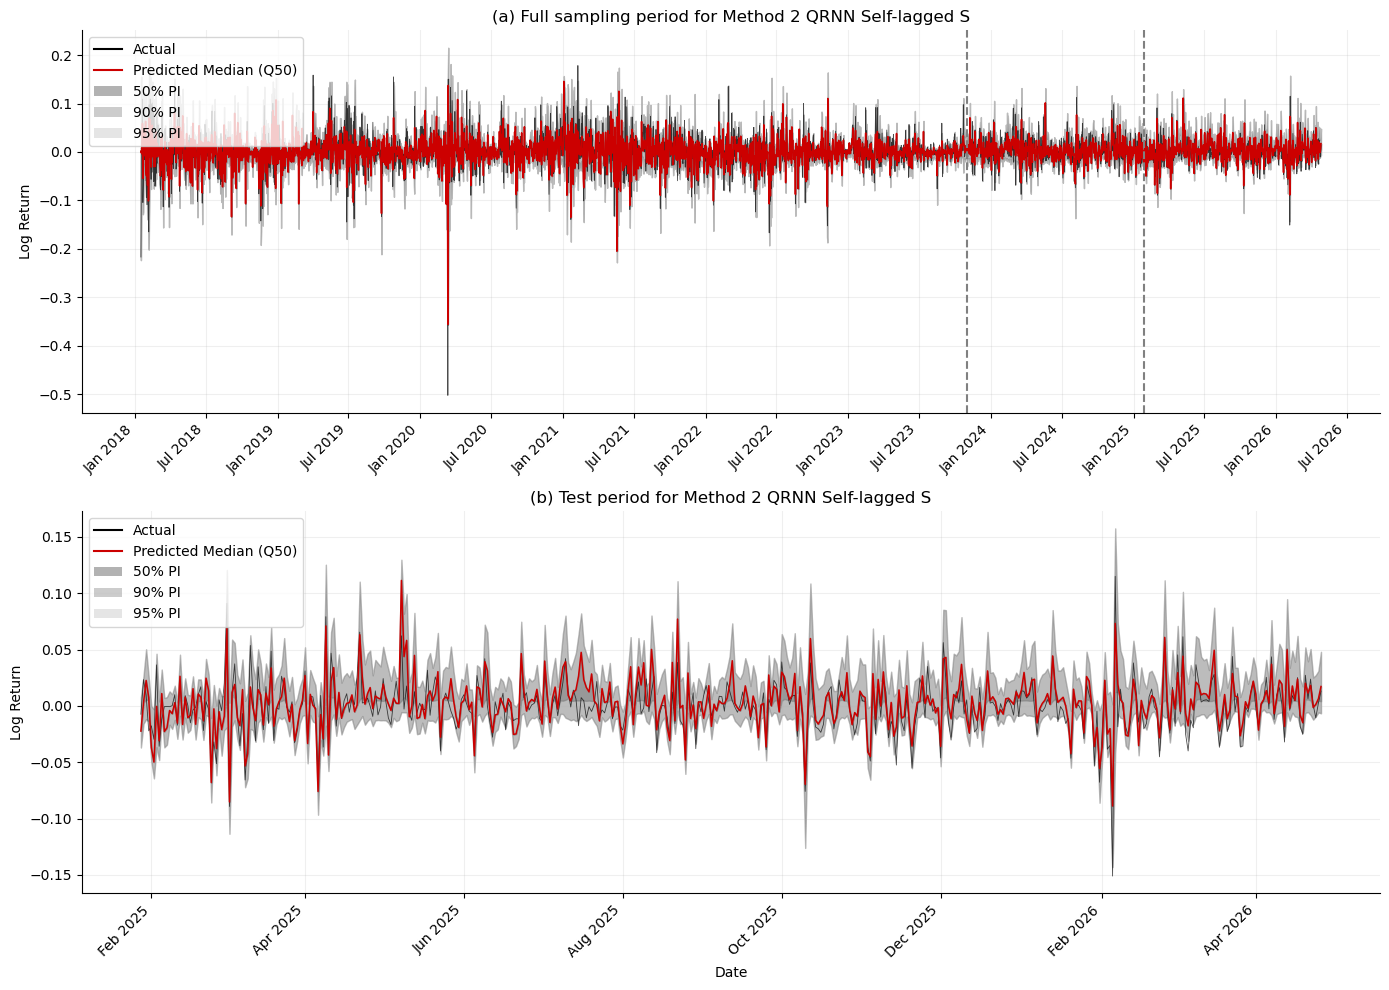

Plot saved to method2_sequential_qrnn_s_self_predictions.png

TEST METRICS -- METHOD 2 QRNN S SELF-LAGGED
 alpha       NLL  Hit_Rate      HRE
 0.025 -2.418180  0.081498 0.056498
 0.050 -2.543513  0.081498 0.031498
 0.250 -2.651011  0.475771 0.225771
 0.500 -2.830609  0.640969 0.140969
 0.750 -2.734186  0.640969 0.109031
 0.950 -2.240538  0.993392 0.043392
 0.975 -2.344477  0.993392 0.018392

Average NLL: -2.537502
Average HRE: 0.089364

CROSSOVER ANALYSIS -- FINAL METHOD 2 HYBRID OUTPUT
(0.025, 0.050): 0 (0.00%) <-- TAIL
(0.050, 0.250): 0 (0.00%)
(0.250, 0.500): 0 (0.00%)
(0.500, 0.750): 0 (0.00%)
(0.750, 0.950): 0 (0.00%)
(0.950, 0.975): 0 (0.00%) <-- TAIL

Total violations: 0 (0.00%)
Tail violations: 0 (0.00%)

CONSTRAINT-BINDING RATE -- TEST PERIOD
alpha=0.750 | reference=0.500 | 454/454 (100.00%)
alpha=0.950 | reference=0.750 | 0/454 (0.00%)
alpha=0.975 | reference=0.950 | 454/454 (100.00%)
alpha=0.250 | reference=0.500 | 254/454 (55.95%)
alpha=0.050 | reference=0.250 | 0/454 (0.00

In [45]:

# ============================================================
# PLOT AND EVALUATE METHOD 2 QRNN S SELF-LAGGED
# Run the tuning cell/file first. If the in-memory model dictionary
# is unavailable, this code reloads the saved checkpoint.
# ============================================================

m2_qrnn_self_s_plot_levels = [
    0.025, 0.050, 0.250, 0.500, 0.750, 0.950, 0.975
]

m2_qrnn_self_s_plot_order = [
    0.500, 0.750, 0.950, 0.975, 0.250, 0.050, 0.025
]

m2_qrnn_self_s_plot_reference = {
    0.500: None,
    0.750: 0.500,
    0.950: 0.750,
    0.975: 0.950,
    0.250: 0.500,
    0.050: 0.250,
    0.025: 0.050,
}

m2_qrnn_self_s_plot_direction = {
    0.500: None,
    0.750: 'upper',
    0.950: 'upper',
    0.975: 'upper',
    0.250: 'lower',
    0.050: 'lower',
    0.025: 'lower',
}


# ============================================================
# Restore models if the tuning dictionary is not in memory
# ============================================================

if 'm2_qrnn_self_s_final_models' not in globals():
    checkpoint = torch.load(
        'method2_sequential_qrnn_s_self_best.pt',
        map_location='cpu',
        weights_only=False,
    )

    m2_qrnn_self_s_final_models = {}

    for alpha in checkpoint['estimation_order']:
        model = M2SequentialQRNNSelfS(
            input_dim=X_train.shape[1],
            config=checkpoint['configs'][alpha],
            direction=checkpoint['directions'][alpha],
        )
        model.load_state_dict(checkpoint['model_state_dicts'][alpha])
        model.eval()
        m2_qrnn_self_s_final_models[alpha] = model


# ============================================================
# Generate all seven full-sample forecasts sequentially
# ============================================================

def m2_qrnn_self_s_generate_all_predictions(models, y, X):
    predictions = {}
    caviar_outputs = {}
    raw_fnn_outputs = {}
    constrained_fnn_outputs = {}
    sigma_values = {}

    for alpha in m2_qrnn_self_s_plot_order:
        reference_alpha = m2_qrnn_self_s_plot_reference[alpha]
        reference = (
            None
            if reference_alpha is None
            else predictions[reference_alpha]
        )

        model = models[alpha]
        model.eval()

        with torch.no_grad():
            (
                predictions[alpha],
                caviar_outputs[alpha],
                raw_fnn_outputs[alpha],
                constrained_fnn_outputs[alpha],
                sigma_values[alpha],
            ) = model(y, X, reference)

    return (
        predictions,
        caviar_outputs,
        raw_fnn_outputs,
        constrained_fnn_outputs,
        sigma_values,
    )


m2_qrnn_self_s_X_all = torch.tensor(
    df[feature_cols].values,
    dtype=torch.float32,
)

m2_qrnn_self_s_y_all = torch.tensor(
    df['log_return'].values,
    dtype=torch.float32,
)

(
    m2_qrnn_self_s_all_preds_tensor,
    m2_qrnn_self_s_all_caviar,
    m2_qrnn_self_s_all_raw_fnn,
    m2_qrnn_self_s_all_constrained_fnn,
    m2_qrnn_self_s_sigma,
) = m2_qrnn_self_s_generate_all_predictions(
    models=m2_qrnn_self_s_final_models,
    y=m2_qrnn_self_s_y_all,
    X=m2_qrnn_self_s_X_all,
)

m2_qrnn_self_s_all_preds = {
    alpha: prediction.detach().cpu().numpy()
    for alpha, prediction in m2_qrnn_self_s_all_preds_tensor.items()
}


# ============================================================
# Plot full and test periods
# ============================================================

m2_qrnn_self_s_all_dates = df.index
m2_qrnn_self_s_test_dates = test_df.index
m2_qrnn_self_s_test_start = len(train_df) + len(val_df)

m2_qrnn_self_s_actual = df['log_return'].values
m2_qrnn_self_s_actual_test = test_df['log_return'].values

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

actual_color = '#000000'
median_color = '#CC0000'
interval_color = '#808080'


def m2_qrnn_self_s_draw_panel(ax, dates, actual, start=None):
    def values(alpha):
        series = m2_qrnn_self_s_all_preds[alpha]
        return series if start is None else series[start:]

    ax.plot(dates, actual, color=actual_color, linewidth=0.6, alpha=0.7)
    ax.plot(
        dates,
        values(0.500),
        color=median_color,
        linewidth=1.1,
    )
    ax.fill_between(
        dates,
        values(0.025),
        values(0.975),
        color=interval_color,
        alpha=0.20,
    )
    ax.fill_between(
        dates,
        values(0.050),
        values(0.950),
        color=interval_color,
        alpha=0.40,
    )
    ax.fill_between(
        dates,
        values(0.250),
        values(0.750),
        color=interval_color,
        alpha=0.60,
    )
    ax.set_ylabel('Log Return')
    ax.grid(True, alpha=0.2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


m2_qrnn_self_s_draw_panel(
    axes[0],
    m2_qrnn_self_s_all_dates,
    m2_qrnn_self_s_actual,
)
axes[0].axvline(train_df.index[-1], color='gray', linestyle='--')
axes[0].axvline(val_df.index[-1], color='gray', linestyle='--')
axes[0].set_title(
    '(a) Full sampling period for Method 2 QRNN Self-lagged S'
)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=6))

m2_qrnn_self_s_draw_panel(
    axes[1],
    m2_qrnn_self_s_test_dates,
    m2_qrnn_self_s_actual_test,
    start=m2_qrnn_self_s_test_start,
)
axes[1].set_title('(b) Test period for Method 2 QRNN Self-lagged S')
axes[1].set_xlabel('Date')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))

legend_elements = [
    Line2D([0], [0], color=actual_color, label='Actual'),
    Line2D([0], [0], color=median_color, label='Predicted Median (Q50)'),
    Patch(facecolor=interval_color, alpha=0.60, label='50% PI'),
    Patch(facecolor=interval_color, alpha=0.40, label='90% PI'),
    Patch(facecolor=interval_color, alpha=0.20, label='95% PI'),
]

for axis in axes:
    axis.legend(handles=legend_elements, loc='upper left')
    plt.setp(axis.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()

m2_qrnn_self_s_plot_name = (
    'method2_sequential_qrnn_s_self_predictions.png'
)
plt.savefig(m2_qrnn_self_s_plot_name, dpi=300, bbox_inches='tight')
plt.show()
plt.close()

print(f'Plot saved to {m2_qrnn_self_s_plot_name}')


# ============================================================
# Test metrics
# ============================================================

m2_qrnn_self_s_y_test = m2_qrnn_self_s_y_all[
    m2_qrnn_self_s_test_start:
]
m2_qrnn_self_s_metric_rows = []

for alpha in m2_qrnn_self_s_plot_levels:
    q_test = m2_qrnn_self_s_all_preds_tensor[alpha][
        m2_qrnn_self_s_test_start:
    ]
    sigma = m2_qrnn_self_s_sigma[alpha]
    nll = m2_qrnn_self_s_loss(
        m2_qrnn_self_s_y_test, q_test, sigma, alpha
    ).item()
    hit_rate = (m2_qrnn_self_s_y_test <= q_test).float().mean().item()
    hre = abs(hit_rate - alpha)

    m2_qrnn_self_s_metric_rows.append(
        {
            'alpha': alpha,
            'NLL': nll,
            'Hit_Rate': hit_rate,
            'HRE': hre,
        }
    )

m2_qrnn_self_s_metrics_df = pd.DataFrame(m2_qrnn_self_s_metric_rows)
m2_qrnn_self_s_average_nll = m2_qrnn_self_s_metrics_df['NLL'].mean()
m2_qrnn_self_s_average_hre = m2_qrnn_self_s_metrics_df['HRE'].mean()

print('\n' + '=' * 68)
print('TEST METRICS -- METHOD 2 QRNN S SELF-LAGGED')
print('=' * 68)
print(m2_qrnn_self_s_metrics_df.to_string(index=False))
print(f'\nAverage NLL: {m2_qrnn_self_s_average_nll:.6f}')
print(f'Average HRE: {m2_qrnn_self_s_average_hre:.6f}')


# ============================================================
# Crossover analysis
# ============================================================

m2_qrnn_self_s_pairs = [
    (0.025, 0.050),
    (0.050, 0.250),
    (0.250, 0.500),
    (0.500, 0.750),
    (0.750, 0.950),
    (0.950, 0.975),
]
m2_qrnn_self_s_tail_pairs = [(0.025, 0.050), (0.950, 0.975)]

m2_qrnn_self_s_total = 0
m2_qrnn_self_s_tail_total = 0
m2_qrnn_self_s_crossover_rows = []

print('\n' + '=' * 68)
print('CROSSOVER ANALYSIS -- FINAL METHOD 2 HYBRID OUTPUT')
print('=' * 68)

for lower, upper in m2_qrnn_self_s_pairs:
    lower_test = m2_qrnn_self_s_all_preds_tensor[lower][
        m2_qrnn_self_s_test_start:
    ]
    upper_test = m2_qrnn_self_s_all_preds_tensor[upper][
        m2_qrnn_self_s_test_start:
    ]
    violations = int((lower_test > upper_test).sum().item())
    rate = violations / len(lower_test)

    m2_qrnn_self_s_total += violations
    if (lower, upper) in m2_qrnn_self_s_tail_pairs:
        m2_qrnn_self_s_tail_total += violations

    m2_qrnn_self_s_crossover_rows.append(
        {
            'Lower': lower,
            'Upper': upper,
            'Violations': violations,
            'Rate': rate,
        }
    )

    tail_label = (
        ' <-- TAIL'
        if (lower, upper) in m2_qrnn_self_s_tail_pairs
        else ''
    )
    print(
        f'({lower:.3f}, {upper:.3f}): '
        f'{violations} ({100 * rate:.2f}%){tail_label}'
    )

m2_qrnn_self_s_total_rate = m2_qrnn_self_s_total / (
    len(m2_qrnn_self_s_y_test) * len(m2_qrnn_self_s_pairs)
)
m2_qrnn_self_s_tail_rate = m2_qrnn_self_s_tail_total / (
    len(m2_qrnn_self_s_y_test) * len(m2_qrnn_self_s_tail_pairs)
)

print(
    f'\nTotal violations: {m2_qrnn_self_s_total} '
    f'({100 * m2_qrnn_self_s_total_rate:.2f}%)'
)
print(
    f'Tail violations: {m2_qrnn_self_s_tail_total} '
    f'({100 * m2_qrnn_self_s_tail_rate:.2f}%)'
)


# ============================================================
# Constraint-binding diagnostic
# ============================================================

m2_qrnn_self_s_binding_rows = []

print('\n' + '=' * 68)
print('CONSTRAINT-BINDING RATE -- TEST PERIOD')
print('=' * 68)

for alpha in m2_qrnn_self_s_plot_order:
    direction = m2_qrnn_self_s_plot_direction[alpha]
    reference_alpha = m2_qrnn_self_s_plot_reference[alpha]

    if direction is None:
        continue

    model = m2_qrnn_self_s_final_models[alpha]
    psi = (
        (1.0 - M2_QRNN_SELF_S_PSI_MARGIN)
        * torch.sigmoid(model.psi_raw)
    )
    caviar = m2_qrnn_self_s_all_caviar[alpha][
        m2_qrnn_self_s_test_start:
    ]
    raw_fnn = m2_qrnn_self_s_all_raw_fnn[alpha][
        m2_qrnn_self_s_test_start:
    ]
    reference = m2_qrnn_self_s_all_preds_tensor[reference_alpha][
        m2_qrnn_self_s_test_start:
    ]
    raw_hybrid = psi * caviar + (1.0 - psi) * raw_fnn

    if direction == 'upper':
        binding = raw_hybrid < (
            reference + M2_QRNN_SELF_S_DELTA
        )
    else:
        binding = raw_hybrid > (
            reference - M2_QRNN_SELF_S_DELTA
        )

    binding_count = int(binding.sum().item())
    binding_rate = binding.float().mean().item()

    m2_qrnn_self_s_binding_rows.append(
        {
            'Alpha': alpha,
            'Reference': reference_alpha,
            'Direction': direction,
            'Binding_Count': binding_count,
            'Binding_Rate': binding_rate,
        }
    )
    print(
        f'alpha={alpha:.3f} | reference={reference_alpha:.3f} | '
        f'{binding_count}/{len(binding)} ({100 * binding_rate:.2f}%)'
    )


# ============================================================
# Save outputs
# ============================================================

m2_qrnn_self_s_metrics_df.to_csv(
    'method2_sequential_qrnn_s_self_test_metrics.csv',
    index=False,
)
pd.DataFrame(m2_qrnn_self_s_crossover_rows).to_csv(
    'method2_sequential_qrnn_s_self_crossover.csv',
    index=False,
)
pd.DataFrame(m2_qrnn_self_s_binding_rows).to_csv(
    'method2_sequential_qrnn_s_self_binding_rates.csv',
    index=False,
)

print('\nSaved Method 2 outputs:')
print('  method2_sequential_qrnn_s_self_predictions.png')
print('  method2_sequential_qrnn_s_self_test_metrics.csv')
print('  method2_sequential_qrnn_s_self_crossover.csv')
print('  method2_sequential_qrnn_s_self_binding_rates.csv')

# Cross over dealing 3

In [48]:
"""Method 3, Specification 1: Hybrid QRNN S self-lagged.

Run this after the notebook has created the four tensors
``y_train``, ``X_train``, ``y_val`` and ``X_val``.

The median is the corresponding original hybrid model.  Every non-median
network predicts a raw adjacent gap; ``softplus`` makes that gap positive and
the target level is reconstructed from its already-fitted adjacent reference.
There is no fixed epsilon boundary, max/min projection, or crossover penalty.
"""

from __future__ import annotations

import copy
from pathlib import Path

import numpy as np
import optuna
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from optuna.samplers import TPESampler


# ---------------------------------------------------------------------------
# User settings
# ---------------------------------------------------------------------------

LEVELS = [0.025, 0.050, 0.250, 0.500, 0.750, 0.950, 0.975]
ESTIMATION_ORDER = [0.500, 0.750, 0.950, 0.975, 0.250, 0.050, 0.025]
REFERENCE_LEVEL = {
    0.500: None,
    0.750: 0.500,
    0.950: 0.750,
    0.975: 0.950,
    0.250: 0.500,
    0.050: 0.250,
    0.025: 0.050,
}
DIRECTION = {
    0.500: None,
    0.750: "upper",
    0.950: "upper",
    0.975: "upper",
    0.250: "lower",
    0.050: "lower",
    0.025: "lower",
}

N_TRIALS = 200
MAX_EPOCHS = 200
BASE_SEED = 2026
PSI_MARGIN = 1e-4
INITIAL_DELTA_BIAS = -4.6  # softplus(-4.6) is about 0.01; trainable.
OUTPUT_DIR = Path("method3_spacing_qrnn_s_self_results")

# This standalone chunk estimates only the model supplied by the user:
# Hybrid QRNN, symmetric form, self-lagged recursion.
MODELS_TO_RUN = [("qrnn", "s", "self")]


def validate_notebook_inputs():
    required = ("y_train", "X_train", "y_val", "X_val")
    missing = [name for name in required if name not in globals()]
    if missing:
        raise NameError(
            "Create these notebook tensors before running Method 3: "
            + ", ".join(missing)
        )
    for y_name, x_name in (("y_train", "X_train"), ("y_val", "X_val")):
        y_value, x_value = globals()[y_name], globals()[x_name]
        if not isinstance(y_value, torch.Tensor) or not isinstance(x_value, torch.Tensor):
            raise TypeError(f"{y_name} and {x_name} must be torch tensors.")
        if y_value.ndim != 1 or x_value.ndim != 2 or len(y_value) != len(x_value):
            raise ValueError(f"{y_name} must be (T,) and {x_name} must be (T,p).")


# ---------------------------------------------------------------------------
# Generic Method 3 model
# ---------------------------------------------------------------------------

class Method3SpacingModel(nn.Module):
    """One sequential level model.

    direction=None is the median hybrid model.  Otherwise the network is a
    pure learned-spacing model and deliberately has no redundant statistical
    or mixing parameters.
    """

    def __init__(self, input_dim, config, distribution, form, lag, direction=None):
        super().__init__()
        if distribution not in {"qrnn", "ernn"}:
            raise ValueError("distribution must be 'qrnn' or 'ernn'.")
        if form not in {"s", "a", "si"}:
            raise ValueError("form must be 's', 'a', or 'si'.")
        if lag not in {"self", "cross"}:
            raise ValueError("lag must be 'self' or 'cross'.")

        self.distribution = distribution
        self.form = form
        self.lag = lag
        self.direction = direction

        # Statistical and mixing parameters are identifiable only for median.
        if direction is None:
            self.persistence_raw = nn.Parameter(torch.tensor(1.386))
            self.news1_raw = nn.Parameter(torch.tensor(0.3))
            if form in {"a", "si"}:
                self.news2_raw = nn.Parameter(torch.tensor(0.3))
            self.psi_raw = nn.Parameter(torch.tensor(0.0))

        self.sigma_raw = nn.Parameter(torch.tensor(0.5))
        fnn_input_dim = input_dim if direction is None else input_dim + 1
        layers = []
        previous_dim = fnn_input_dim
        for index in range(config["n_hidden_layers"]):
            hidden_dim = config[f"hidden_dim_{index}"]
            layers.append(nn.Linear(previous_dim, hidden_dim))
            if config["layernorm"]:
                layers.append(nn.LayerNorm(hidden_dim))
            layers.append(self._activation(config["activation"]))
            if config["dropout"] > 0:
                layers.append(nn.Dropout(config["dropout"]))
            previous_dim = hidden_dim
        layers.append(nn.Linear(previous_dim, 1))
        self.fnn = nn.Sequential(*layers)
        self._initialise_fnn(config["weight_init"])

        if direction is not None:
            nn.init.constant_(self.fnn[-1].bias, INITIAL_DELTA_BIAS)

    @staticmethod
    def _activation(name):
        return {
            "relu": nn.ReLU(),
            "elu": nn.ELU(),
            "gelu": nn.GELU(),
            "tanh": nn.Tanh(),
        }[name]

    def _initialise_fnn(self, method):
        for module in self.fnn.modules():
            if isinstance(module, nn.Linear):
                if method == "glorot":
                    nn.init.xavier_uniform_(module.weight)
                else:
                    nn.init.kaiming_uniform_(module.weight)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)

    def _statistical_update(self, previous_state, previous_y):
        persistence = torch.sigmoid(self.persistence_raw)
        news1 = F.softplus(self.news1_raw)
        if self.form == "s":
            return persistence * previous_state + news1 * torch.abs(previous_y)
        if self.form == "a":
            news2 = F.softplus(self.news2_raw)
            return (
                persistence * previous_state
                + news1 * torch.clamp(previous_y, min=0)
                + news2 * torch.clamp(-previous_y, min=0)
            )
        news2 = F.softplus(self.news2_raw)
        absolute_y = torch.abs(previous_y)
        return (
            persistence * previous_state
            + news1 * absolute_y
            + news2 * previous_state * absolute_y
        )

    def forward(self, y, X, q_reference=None, initial_state=None, initial_y=None):
        sigma = F.softplus(self.sigma_raw) + 1e-6

        # Six non-median models: directly learn a positive adjacent spacing.
        if self.direction is not None:
            if q_reference is None:
                raise ValueError("Non-median levels require q_reference.")
            reference = q_reference.detach()
            raw_delta = self.fnn(
                torch.cat((X, reference.unsqueeze(1)), dim=1)
            ).squeeze(-1)
            delta = F.softplus(raw_delta)
            prediction = reference + delta if self.direction == "upper" else reference - delta
            return prediction, torch.zeros_like(prediction), raw_delta, delta, sigma

        # Median: original hybrid statistical-neural specification.
        if (initial_state is None) != (initial_y is None):
            raise ValueError("initial_state and initial_y must be supplied together.")
        has_initial_state = initial_state is not None
        previous_state = initial_state if has_initial_state else y.new_zeros(())
        fnn_median = self.fnn(X).squeeze(-1)
        psi = (1.0 - PSI_MARGIN) * torch.sigmoid(self.psi_raw)
        predictions, statistical_outputs = [], []

        for t in range(len(y)):
            if t == 0 and not has_initial_state:
                statistical_t = y.new_zeros(())
                hybrid_t = y.new_zeros(())
            else:
                previous_y = initial_y if t == 0 else y[t - 1]
                statistical_t = self._statistical_update(previous_state, previous_y)
                hybrid_t = psi * statistical_t + (1.0 - psi) * fnn_median[t]
            statistical_outputs.append(statistical_t)
            predictions.append(hybrid_t)
            # Settled convention used by the earlier code:
            # self -> previous pure statistical output; cross -> previous hybrid.
            previous_state = statistical_t if self.lag == "self" else hybrid_t

        prediction = torch.stack(predictions)
        statistical = torch.stack(statistical_outputs)
        return prediction, statistical, fnn_median, None, sigma


# ---------------------------------------------------------------------------
# Distribution-specific objectives and calibration metrics
# ---------------------------------------------------------------------------

def single_level_nll(y, location, sigma, level, distribution):
    residual = y - location
    level_tensor = torch.tensor(level, dtype=y.dtype, device=y.device)
    if distribution == "qrnn":
        indicator = (residual < 0).to(y.dtype)
        rho = residual * (level_tensor - indicator)
        return (
            -torch.log(level_tensor * (1.0 - level_tensor))
            + torch.log(sigma)
            + rho / sigma
        ).mean()

    weight = torch.abs(level_tensor - (residual < 0).to(y.dtype))
    omega = weight * residual.square()
    constant = (
        torch.log(
            torch.sqrt(torch.pi / level_tensor)
            + torch.sqrt(torch.pi / (1.0 - level_tensor))
        )
        - np.log(2.0)
    )
    return (torch.log(sigma) + constant + omega / sigma.square()).mean()


def qrnn_calibration(y, location, level):
    if level <= 0.5:
        empirical = (y <= location).float().mean().item()
        target = level
    else:
        empirical = (y > location).float().mean().item()
        target = 1.0 - level
    crp = empirical / target
    return {"hit_rate": (y <= location).float().mean().item(),
            "hre": abs((y <= location).float().mean().item() - level),
            "calibration": crp,
            "calibration_penalty": (crp - 1.0) ** 2}


def ernn_calibration(y, location, level):
    residual = y - location
    weights = torch.where(
        residual >= 0,
        torch.full_like(residual, level),
        torch.full_like(residual, 1.0 - level),
    )
    ase = (weights * residual.square()).mean().item()
    return {"ase": ase, "calibration": ase, "calibration_penalty": ase}


# ---------------------------------------------------------------------------
# Tuning helpers
# ---------------------------------------------------------------------------

def suggest_config(trial):
    config = {
        "n_hidden_layers": trial.suggest_int("n_hidden_layers", 1, 3),
        "activation": trial.suggest_categorical("activation", ["relu", "elu", "gelu", "tanh"]),
        "dropout": trial.suggest_float("dropout", 0.0, 0.5),
        "layernorm": trial.suggest_categorical("layernorm", [True, False]),
        "weight_init": trial.suggest_categorical("weight_init", ["glorot", "he"]),
        "lr": trial.suggest_float("lr", 1e-4, 5e-2, log=True),
        "optimizer": trial.suggest_categorical("optimizer", ["adam", "adamw"]),
        "weight_decay": trial.suggest_float("weight_decay", 0.0, 1e-4),
        "gradient_clip": trial.suggest_categorical("gradient_clip", [0.1, 1.0, 5.0]),
        "patience": trial.suggest_categorical("patience", [10, 20, 30]),
    }
    for index in range(config["n_hidden_layers"]):
        config[f"hidden_dim_{index}"] = trial.suggest_int(f"hidden_dim_{index}", 32, 256)
    return config


def make_optimizer(model, config):
    optimizer_class = torch.optim.Adam if config["optimizer"] == "adam" else torch.optim.AdamW
    return optimizer_class(model.parameters(), lr=config["lr"], weight_decay=config["weight_decay"])


def median_validation_state(model, statistical_train, prediction_train):
    return statistical_train[-1] if model.lag == "self" else prediction_train[-1]


def predict_train_val(model, direction, q_reference_train=None, q_reference_val=None):
    model.eval()
    with torch.no_grad():
        q_train, stat_train, _, delta_train, _ = model(
            y_train, X_train, q_reference_train
        )
        if direction is None:
            q_val, _, _, delta_val, sigma = model(
                y_val,
                X_val,
                initial_state=median_validation_state(model, stat_train, q_train),
                initial_y=y_train[-1],
            )
        else:
            q_val, _, _, delta_val, sigma = model(y_val, X_val, q_reference_val)
    return q_train.detach(), q_val.detach(), delta_train, delta_val, sigma.detach()


def train_config(spec, config, level, direction, q_ref_train, q_ref_val, seed):
    distribution, form, lag = spec
    torch.manual_seed(seed)
    model = Method3SpacingModel(
        X_train.shape[1], config, distribution, form, lag, direction
    )
    optimizer = make_optimizer(model, config)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", patience=10, factor=0.5, min_lr=1e-6
    )
    best_loss, counter, best_state = float("inf"), 0, None

    for _ in range(MAX_EPOCHS):
        model.train()
        optimizer.zero_grad()
        q_train, _, _, _, sigma = model(y_train, X_train, q_ref_train)
        loss = single_level_nll(y_train[1:], q_train[1:], sigma, level, distribution)
        if not torch.isfinite(loss):
            return None
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), config["gradient_clip"])
        optimizer.step()

        model.eval()
        with torch.no_grad():
            _, q_val, _, _, sigma_val = predict_train_val(
                model, direction, q_ref_train, q_ref_val
            )
            val_loss = single_level_nll(y_val, q_val, sigma_val, level, distribution)
        scheduler.step(val_loss.item())
        if val_loss.item() < best_loss:
            best_loss, counter = val_loss.item(), 0
            best_state = copy.deepcopy(model.state_dict())
        else:
            counter += 1
            if counter >= config["patience"]:
                break

    if best_state is None:
        return None
    model.load_state_dict(best_state)
    return model


def transformed_median_parameters(model):
    if model.direction is not None:
        return {}
    result = {
        "persistence": torch.sigmoid(model.persistence_raw).item(),
        "news1": F.softplus(model.news1_raw).item(),
        "psi": ((1.0 - PSI_MARGIN) * torch.sigmoid(model.psi_raw)).item(),
    }
    result["news2"] = (
        F.softplus(model.news2_raw).item() if hasattr(model, "news2_raw") else np.nan
    )
    return result


def evaluate(model, level, direction, q_ref_train, q_ref_val):
    _, q_val, _, delta_val, sigma = predict_train_val(
        model, direction, q_ref_train, q_ref_val
    )
    metrics = {
        "nll": single_level_nll(
            y_val, q_val, sigma, level, model.distribution
        ).item(),
        "sigma": (F.softplus(model.sigma_raw) + 1e-6).item(),
        "mean_delta": np.nan if delta_val is None else delta_val.mean().item(),
        "min_delta": np.nan if delta_val is None else delta_val.min().item(),
        "max_delta": np.nan if delta_val is None else delta_val.max().item(),
        "sd_delta": np.nan if delta_val is None else delta_val.std(unbiased=False).item(),
    }
    metrics.update(
        qrnn_calibration(y_val, q_val, level)
        if model.distribution == "qrnn"
        else ernn_calibration(y_val, q_val, level)
    )
    metrics.update(transformed_median_parameters(model))
    return metrics


def select_trial(study):
    trials = [
        trial for trial in study.trials
        if trial.state == optuna.trial.TrialState.COMPLETE
        and trial.value is not None
        and np.isfinite(trial.value)
        and "calibration_penalty" in trial.user_attrs
    ]
    if not trials:
        raise RuntimeError("No valid completed Optuna trials.")
    for rank, trial in enumerate(sorted(trials, key=lambda x: x.user_attrs["nll"]), 1):
        trial._rank_nll = rank
    for rank, trial in enumerate(
        sorted(trials, key=lambda x: x.user_attrs["calibration_penalty"]), 1
    ):
        trial._rank_calibration = rank
    best = min(
        trials,
        key=lambda x: (
            x._rank_nll + x._rank_calibration,
            x.user_attrs["nll"],
            x.user_attrs["calibration_penalty"],
            x.number,
        ),
    )
    return best, trials


def count_crossovers(predictions):
    matrix = torch.stack([predictions[level] for level in LEVELS], dim=1)
    violations = matrix[:, :-1] > matrix[:, 1:]
    pair_counts = violations.sum(dim=0)
    return {
        "crossover": int(violations.sum().item()),
        "tail": int((pair_counts[0] + pair_counts[-1]).item()),
    }


def run_one_model(spec):
    distribution, form, lag = spec
    model_key = f"{distribution}_{form}_{lag}"
    model_dir = OUTPUT_DIR / model_key
    model_dir.mkdir(parents=True, exist_ok=True)
    print("\n" + "=" * 78)
    print(f"METHOD 3 SPACING: {distribution.upper()} {form.upper()} {lag.upper()}")
    print("=" * 78)

    models, configs, metrics_by_level = {}, {}, {}
    train_predictions, val_predictions = {}, {}
    train_deltas, val_deltas = {}, {}

    for order_index, level in enumerate(ESTIMATION_ORDER):
        reference_level = REFERENCE_LEVEL[level]
        direction = DIRECTION[level]
        q_ref_train = None if reference_level is None else train_predictions[reference_level]
        q_ref_val = None if reference_level is None else val_predictions[reference_level]
        seed = BASE_SEED + 1000 * MODELS_TO_RUN.index(spec) + order_index

        def objective(trial):
            config = suggest_config(trial)
            model = train_config(
                spec, config, level, direction, q_ref_train, q_ref_val, seed
            )
            if model is None:
                return float("inf")
            trial_metrics = evaluate(model, level, direction, q_ref_train, q_ref_val)
            for name, value in trial_metrics.items():
                trial.set_user_attr(name, value)
            return trial_metrics["nll"]

        print(
            f"Level={level:.3f} | reference={reference_level} | "
            f"direction={direction} | trials={N_TRIALS}"
        )
        study = optuna.create_study(
            direction="minimize", sampler=TPESampler(seed=seed)
        )
        study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)
        best_trial, valid_trials = select_trial(study)

        ranking_records = []
        for trial in valid_trials:
            record = {
                "distribution": distribution,
                "form": form,
                "lag": lag,
                "level": level,
                "reference_level": reference_level,
                "direction": direction,
                "trial": trial.number,
                "nll": trial.user_attrs["nll"],
                "calibration": trial.user_attrs["calibration"],
                "calibration_penalty": trial.user_attrs["calibration_penalty"],
                "rank_nll": trial._rank_nll,
                "rank_calibration": trial._rank_calibration,
                "sum_rank": trial._rank_nll + trial._rank_calibration,
            }
            record.update(trial.user_attrs)
            record.update(trial.params)
            ranking_records.append(record)
        pd.DataFrame(ranking_records).sort_values(
            ["sum_rank", "nll", "calibration_penalty"]
        ).to_csv(model_dir / f"ranking_level_{level:.3f}.csv", index=False)

        best_config = best_trial.params.copy()
        final_model = train_config(
            spec, best_config, level, direction, q_ref_train, q_ref_val, seed
        )
        if final_model is None:
            raise RuntimeError(f"Selected refit failed for {model_key}, level={level}.")
        final_metrics = evaluate(
            final_model, level, direction, q_ref_train, q_ref_val
        )
        q_train, q_val, delta_train, delta_val, _ = predict_train_val(
            final_model, direction, q_ref_train, q_ref_val
        )
        models[level], configs[level] = final_model, best_config
        metrics_by_level[level] = final_metrics
        train_predictions[level], val_predictions[level] = q_train, q_val
        train_deltas[level], val_deltas[level] = delta_train, delta_val

        print(
            f"Selected trial #{best_trial.number} | "
            f"val NLL={final_metrics['nll']:.6f} | "
            f"calibration={final_metrics['calibration']:.6f} | "
            f"mean delta={final_metrics['mean_delta']:.6f}"
        )

    crossing = count_crossovers(val_predictions)
    average_nll = float(np.mean([metrics_by_level[x]["nll"] for x in LEVELS]))
    if distribution == "qrnn":
        average_secondary = float(np.mean([metrics_by_level[x]["hre"] for x in LEVELS]))
        secondary_name = "hre"
    else:
        average_secondary = float(np.mean([metrics_by_level[x]["ase"] for x in LEVELS]))
        secondary_name = "ase"

    checkpoint = {
        "model_name": f"Method 3 spacing {distribution.upper()} {form.upper()} {lag}",
        "specification": "learned_positive_time_varying_adjacent_spacing",
        "distribution": distribution,
        "form": form,
        "lag": lag,
        "levels": LEVELS,
        "estimation_order": ESTIMATION_ORDER,
        "reference_level": REFERENCE_LEVEL,
        "direction": DIRECTION,
        "configs": configs,
        "model_state_dicts": {level: model.state_dict() for level, model in models.items()},
        "validation_metrics": metrics_by_level,
        "validation_summary": {
            "average_nll": average_nll,
            f"average_{secondary_name}": average_secondary,
            **crossing,
        },
    }
    checkpoint_path = model_dir / f"method3_spacing_{model_key}_best.pt"
    torch.save(checkpoint, checkpoint_path)

    level_rows = []
    for level in LEVELS:
        level_rows.append({"level": level, **metrics_by_level[level]})
    pd.DataFrame(level_rows).to_csv(model_dir / "validation_by_level.csv", index=False)

    summary = {
        "distribution": distribution,
        "form": form.upper(),
        "lag": lag,
        "average_nll": average_nll,
        "average_hre": average_secondary if distribution == "qrnn" else np.nan,
        "average_ase": average_secondary if distribution == "ernn" else np.nan,
        **crossing,
        "checkpoint": str(checkpoint_path),
    }
    pd.DataFrame([summary]).to_csv(model_dir / "validation_summary.csv", index=False)
    print(f"Saved {checkpoint_path}")
    return summary


def main():
    validate_notebook_inputs()
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    summaries = []
    for spec in MODELS_TO_RUN:
        summaries.append(run_one_model(spec))
        pd.DataFrame(summaries).to_csv(
            OUTPUT_DIR / "method3_qrnn_s_self_validation_summary.csv", index=False
        )
    print("\nMethod 3 QRNN S self-lagged estimation is complete.")
    print(pd.DataFrame(summaries).to_string(index=False))


if __name__ == "__main__":
    main()

[I 2026-08-16 16:29:01,847] A new study created in memory with name: no-name-124f250a-a4cf-4bf8-9552-5d9db2cb9318



METHOD 3 SPACING: QRNN S SELF
Level=0.500 | reference=None | direction=None | trials=200


  0%|          | 0/200 [00:00<?, ?it/s]

[I 2026-08-16 16:29:56,028] Trial 0 finished with value: 1.2921350002288818 and parameters: {'n_hidden_layers': 1, 'activation': 'elu', 'dropout': 0.49377524711883497, 'layernorm': False, 'weight_init': 'he', 'lr': 0.0006552020421842752, 'optimizer': 'adam', 'weight_decay': 8.940884610144999e-05, 'gradient_clip': 5.0, 'patience': 30, 'hidden_dim_0': 38}. Best is trial 0 with value: 1.2921350002288818.
[I 2026-08-16 16:30:46,410] Trial 1 finished with value: 0.25190040469169617 and parameters: {'n_hidden_layers': 1, 'activation': 'tanh', 'dropout': 0.07458356653667625, 'layernorm': False, 'weight_init': 'he', 'lr': 0.006969178688110181, 'optimizer': 'adam', 'weight_decay': 2.574006001095316e-05, 'gradient_clip': 1.0, 'patience': 30, 'hidden_dim_0': 102}. Best is trial 1 with value: 0.25190040469169617.
[I 2026-08-16 16:30:53,191] Trial 2 finished with value: 1.402778148651123 and parameters: {'n_hidden_layers': 1, 'activation': 'tanh', 'dropout': 0.37112272198735796, 'layernorm': True, 

[I 2026-08-16 18:33:12,453] A new study created in memory with name: no-name-4b469118-cd50-41a1-bed3-f27d80d54741


...

[I 2026-08-16 20:27:47,024] Trial 0 finished with value: 1.9723308086395264 and parameters: {'n_hidden_layers': 2, 'activation': 'tanh', 'dropout': 0.11155263989652436, 'layernorm': False, 'weight_init': 'glorot', 'lr': 0.007027131382827591, 'optimizer': 'adam', 'weight_decay': 1.3627456384020455e-05, 'gradient_clip': 0.1, 'patience': 20, 'hidden_dim_0': 210, 'hidden_dim_1': 162}. Best is trial 0 with value: 1.9723308086395264.
[I 2026-08-16 20:27:50,150] Trial 1 finished with value: 0.7043174505233765 and parameters: {'n_hidden_layers': 3, 'activation': 'elu', 'dropout': 0.09630890988459678, 'layernorm': False, 'weight_init': 'he', 'lr': 0.014080280114638532, 'optimizer': 'adam', 'weight_decay': 6.431370011304687e-05, 'gradient_clip': 0.1, 'patience': 10, 'hidden_dim_0': 88, 'hidden_dim_1': 196, 'hidden_dim_2': 94}. Best is trial 1 with value: 0.7043174505233765.
[I 2026-08-16 20:27:51,934] Trial 2 finished with value: 2.917412042617798 and parameters: {'n_hidden_layers': 2, 'activati

[I 2026-08-16 22:13:50,677] A new study created in memory with name: no-name-33caabe9-8843-44aa-a481-d6be5492d94d


Selected trial #129 | val NLL=-2.352630 | calibration=1.015453 | mean delta=0.014645
Level=0.025 | reference=0.05 | direction=lower | trials=200


  0%|          | 0/200 [00:00<?, ?it/s]

[I 2026-08-16 22:13:54,557] Trial 0 finished with value: 2.490286111831665 and parameters: {'n_hidden_layers': 3, 'activation': 'relu', 'dropout': 0.11110238679748752, 'layernorm': False, 'weight_init': 'he', 'lr': 0.007412946243424984, 'optimizer': 'adam', 'weight_decay': 2.0378044529961404e-05, 'gradient_clip': 5.0, 'patience': 20, 'hidden_dim_0': 189, 'hidden_dim_1': 194, 'hidden_dim_2': 105}. Best is trial 0 with value: 2.490286111831665.
[I 2026-08-16 22:13:58,032] Trial 1 finished with value: 3.3956096172332764 and parameters: {'n_hidden_layers': 3, 'activation': 'elu', 'dropout': 0.40125521853112683, 'layernorm': False, 'weight_init': 'he', 'lr': 0.002129411642087111, 'optimizer': 'adamw', 'weight_decay': 1.3495676574961092e-06, 'gradient_clip': 5.0, 'patience': 20, 'hidden_dim_0': 133, 'hidden_dim_1': 222, 'hidden_dim_2': 66}. Best is trial 0 with value: 2.490286111831665.
[I 2026-08-16 22:13:59,431] Trial 2 finished with value: 3.539726972579956 and parameters: {'n_hidden_laye

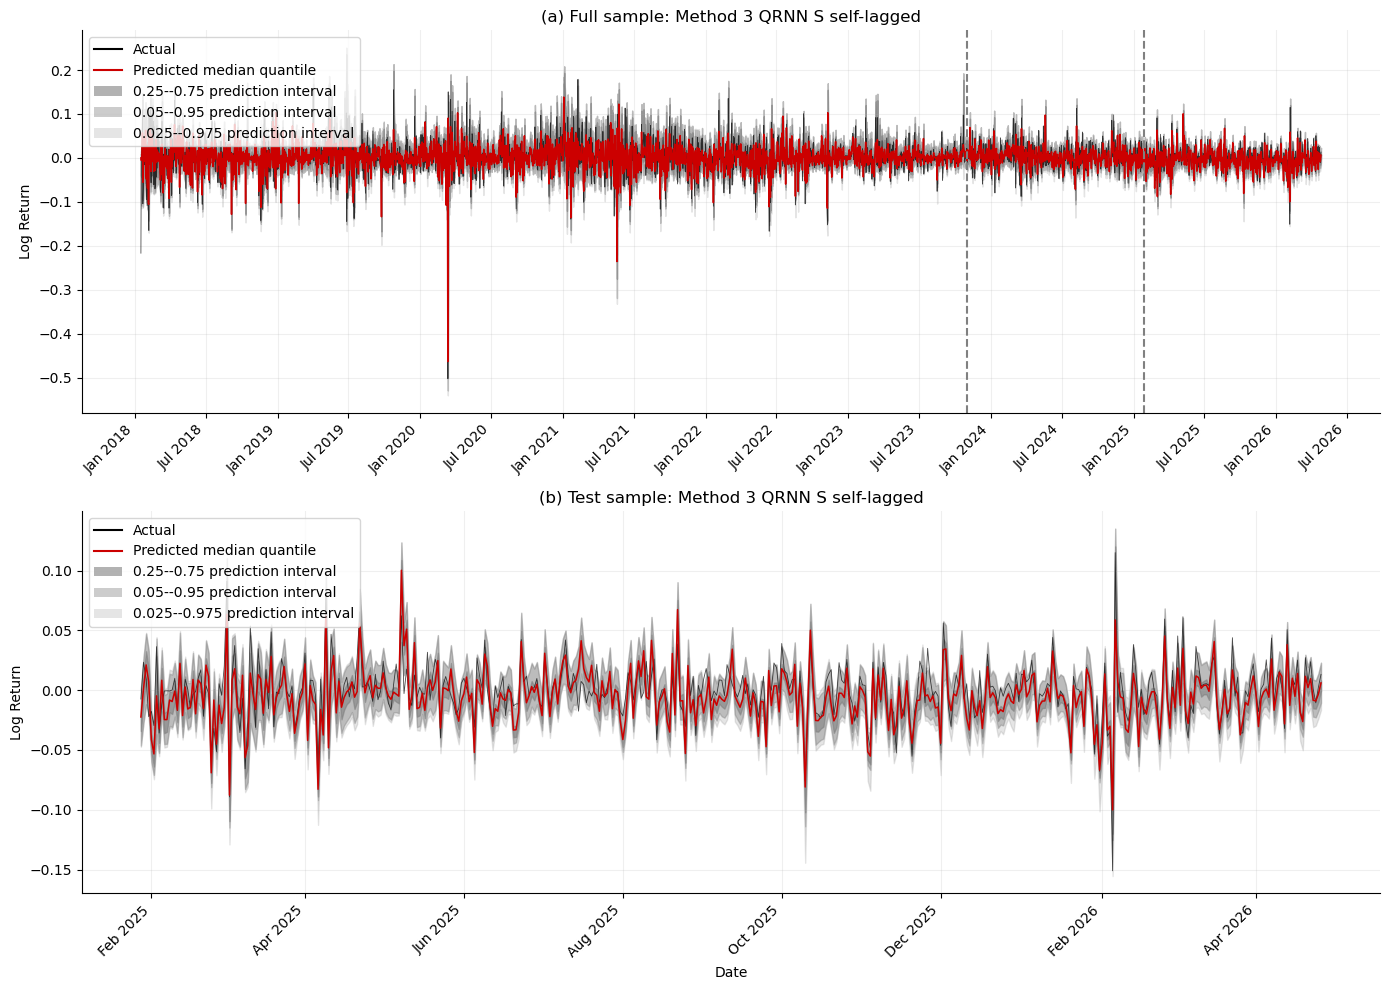


METHOD 3 QRNN S SELF-LAGGED -- TEST RESULTS
               model  test_T  average_nll  average_hre  crossover  tail
Method 3 QRNN S Self     454     -2.56985     0.099434          0     0

Per-level results:
 alpha       nll  hit_rate      hre    sigma
 0.025 -2.379165  0.019824 0.005176 0.000919
 0.050 -2.509852  0.035242 0.014758 0.001765
 0.250 -2.723432  0.147577 0.102423 0.005503
 0.500 -2.755388  0.310573 0.189427 0.008083
 0.750 -2.642145  0.471366 0.278634 0.004742
 0.950 -2.559707  0.894273 0.055727 0.001666
 0.975 -2.419261  0.925110 0.049890 0.000890

Learned-spacing diagnostics:
 alpha  reference_alpha direction  mean_delta  min_delta  max_delta  sd_delta  near_zero_count  near_zero_rate
 0.025             0.05     lower    0.005231   0.000118   0.030519  0.003702                0             0.0
 0.050             0.25     lower    0.010219   0.002950   0.053436  0.005373                0             0.0
 0.250             0.50     lower    0.007544   0.005639   0.021727 

In [50]:
"""Plot and evaluate Method 3 QRNN S self-lagged on the test sample.

Run after the tuning/data-preparation code. Expected notebook objects:
df, train_df, val_df, test_df, feature_cols, X_train and Method3SpacingModel.
"""

from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from matplotlib.lines import Line2D
from matplotlib.patches import Patch


LEVELS = [0.025, 0.050, 0.250, 0.500, 0.750, 0.950, 0.975]
ORDER = [0.500, 0.750, 0.950, 0.975, 0.250, 0.050, 0.025]
REFERENCE = {
    0.500: None,
    0.750: 0.500,
    0.950: 0.750,
    0.975: 0.950,
    0.250: 0.500,
    0.050: 0.250,
    0.025: 0.050,
}
DIRECTION = {
    0.500: None,
    0.750: "upper",
    0.950: "upper",
    0.975: "upper",
    0.250: "lower",
    0.050: "lower",
    0.025: "lower",
}

MODEL_DIR = Path("method3_spacing_qrnn_s_self_results") / "qrnn_s_self"
CHECKPOINT_PATH = MODEL_DIR / "method3_spacing_qrnn_s_self_best.pt"
PLOT_PATH = MODEL_DIR / "method3_spacing_qrnn_s_self.png"
METRICS_PATH = MODEL_DIR / "method3_spacing_qrnn_s_self_test_metrics.csv"
SUMMARY_PATH = MODEL_DIR / "method3_spacing_qrnn_s_self_test_summary.csv"
DELTA_PATH = MODEL_DIR / "method3_spacing_qrnn_s_self_delta_summary.csv"
PREDICTIONS_PATH = MODEL_DIR / "method3_spacing_qrnn_s_self_test_predictions.csv"


required_objects = (
    "df", "train_df", "val_df", "test_df", "feature_cols", "X_train"
)
missing = [name for name in required_objects if name not in globals()]
if missing:
    raise NameError("Run the data-preparation cells first. Missing: " + ", ".join(missing))

if "Method3SpacingModel" not in globals():
    from method3_spacing_qrnn_s_self_tuning import Method3SpacingModel

if not CHECKPOINT_PATH.exists():
    raise FileNotFoundError(
        f"Checkpoint not found: {CHECKPOINT_PATH}. Run the tuning code first."
    )


# ---------------------------------------------------------------------------
# Reload all seven selected level models
# ---------------------------------------------------------------------------

checkpoint = torch.load(CHECKPOINT_PATH, map_location="cpu", weights_only=False)
if checkpoint.get("distribution") != "qrnn":
    raise ValueError("The checkpoint is not a QRNN checkpoint.")
if checkpoint.get("form") != "s" or checkpoint.get("lag") != "self":
    raise ValueError("The checkpoint is not the QRNN S self-lagged model.")

models = {}
for level in ORDER:
    model = Method3SpacingModel(
        input_dim=X_train.shape[1],
        config=checkpoint["configs"][level],
        distribution="qrnn",
        form="s",
        lag="self",
        direction=checkpoint["direction"][level],
    )
    model.load_state_dict(checkpoint["model_state_dicts"][level])
    model.eval()
    models[level] = model


# ---------------------------------------------------------------------------
# Generate full-sample forecasts sequentially from the median outwards
# ---------------------------------------------------------------------------

X_all = torch.tensor(df[feature_cols].values, dtype=torch.float32)
y_all = torch.tensor(df["log_return"].values, dtype=torch.float32)
predictions, deltas, sigmas = {}, {}, {}

for level in ORDER:
    reference_level = REFERENCE[level]
    reference = None if reference_level is None else predictions[reference_level]
    with torch.no_grad():
        prediction, _, _, delta, sigma = models[level](y_all, X_all, reference)
    predictions[level] = prediction.detach()
    deltas[level] = None if delta is None else delta.detach()
    sigmas[level] = sigma.detach()

test_start = len(train_df) + len(val_df)
y_test = y_all[test_start:]
test_dates = test_df.index

if len(y_test) != len(test_dates):
    raise ValueError("The calculated test slice does not match test_df.")


# ---------------------------------------------------------------------------
# Plot full sample and test sample
# ---------------------------------------------------------------------------

prediction_np = {level: predictions[level].cpu().numpy() for level in LEVELS}
actual_np = df["log_return"].to_numpy()


def draw_panel(axis, dates, actual, start=None):
    def values(level):
        series = prediction_np[level]
        return series if start is None else series[start:]

    axis.plot(dates, actual, color="#000000", linewidth=0.6, alpha=0.70)
    axis.plot(dates, values(0.500), color="#CC0000", linewidth=1.1)
    axis.fill_between(dates, values(0.025), values(0.975), color="#808080", alpha=0.20)
    axis.fill_between(dates, values(0.050), values(0.950), color="#808080", alpha=0.40)
    axis.fill_between(dates, values(0.250), values(0.750), color="#808080", alpha=0.60)
    axis.set_ylabel("Log Return")
    axis.grid(True, alpha=0.20)
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)


figure, axes = plt.subplots(2, 1, figsize=(14, 10))
draw_panel(axes[0], df.index, actual_np)
axes[0].axvline(train_df.index[-1], color="gray", linestyle="--")
axes[0].axvline(val_df.index[-1], color="gray", linestyle="--")
axes[0].set_title("(a) Full sample: Method 3 QRNN S self-lagged")
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=6))
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

draw_panel(axes[1], test_dates, test_df["log_return"].to_numpy(), start=test_start)
axes[1].set_title("(b) Test sample: Method 3 QRNN S self-lagged")
axes[1].set_xlabel("Date")
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

legend = [
    Line2D([0], [0], color="#000000", label="Actual"),
    Line2D([0], [0], color="#CC0000", label="Predicted median quantile"),
    Patch(facecolor="#808080", alpha=0.60, label="0.25--0.75 prediction interval"),
    Patch(facecolor="#808080", alpha=0.40, label="0.05--0.95 prediction interval"),
    Patch(facecolor="#808080", alpha=0.20, label="0.025--0.975 prediction interval"),
]
for axis in axes:
    axis.legend(handles=legend, loc="upper left")
    plt.setp(axis.xaxis.get_majorticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.savefig(PLOT_PATH, dpi=300, bbox_inches="tight")
plt.show()
plt.close()


# ---------------------------------------------------------------------------
# Test ALD NLL, hit rate and HRE
# ---------------------------------------------------------------------------


def ald_nll(y, quantile, sigma, alpha):
    residual = y - quantile
    alpha_tensor = torch.tensor(alpha, dtype=y.dtype, device=y.device)
    indicator = (residual < 0).to(y.dtype)
    check_loss = residual * (alpha_tensor - indicator)
    return (
        -torch.log(alpha_tensor * (1.0 - alpha_tensor))
        + torch.log(sigma)
        + check_loss / sigma
    ).mean()


metric_rows = []
for level in LEVELS:
    prediction_test = predictions[level][test_start:]
    hit_rate = (y_test <= prediction_test).float().mean().item()
    metric_rows.append({
        "alpha": level,
        "nll": ald_nll(y_test, prediction_test, sigmas[level], level).item(),
        "hit_rate": hit_rate,
        "hre": abs(hit_rate - level),
        "sigma": sigmas[level].item(),
    })

metrics_df = pd.DataFrame(metric_rows)
metrics_df.to_csv(METRICS_PATH, index=False)


# ---------------------------------------------------------------------------
# Crossover and learned-spacing diagnostics
# ---------------------------------------------------------------------------

test_matrix = torch.stack(
    [predictions[level][test_start:] for level in LEVELS], dim=1
)
violations = test_matrix[:, :-1] > test_matrix[:, 1:]
pair_counts = violations.sum(dim=0)
total_crossover = int(violations.sum().item())
tail_crossover = int((pair_counts[0] + pair_counts[-1]).item())

delta_rows = []
for level in LEVELS:
    if deltas[level] is None:
        continue
    delta_test = deltas[level][test_start:]
    delta_rows.append({
        "alpha": level,
        "reference_alpha": REFERENCE[level],
        "direction": DIRECTION[level],
        "mean_delta": delta_test.mean().item(),
        "min_delta": delta_test.min().item(),
        "max_delta": delta_test.max().item(),
        "sd_delta": delta_test.std(unbiased=False).item(),
        "near_zero_count": int((delta_test < 1e-6).sum().item()),
        "near_zero_rate": (delta_test < 1e-6).float().mean().item(),
    })

delta_df = pd.DataFrame(delta_rows)
delta_df.to_csv(DELTA_PATH, index=False)

summary_df = pd.DataFrame([{
    "model": "Method 3 QRNN S Self",
    "test_T": len(y_test),
    "average_nll": metrics_df["nll"].mean(),
    "average_hre": metrics_df["hre"].mean(),
    "crossover": total_crossover,
    "tail": tail_crossover,
}])
summary_df.to_csv(SUMMARY_PATH, index=False)


# ---------------------------------------------------------------------------
# Detailed test predictions and adjacent gaps
# ---------------------------------------------------------------------------

prediction_table = pd.DataFrame({
    "date": test_dates,
    "actual": y_test.cpu().numpy(),
})
for level in LEVELS:
    prediction_table[f"q_{level:.3f}"] = predictions[level][test_start:].cpu().numpy()
for left, right in zip(LEVELS[:-1], LEVELS[1:]):
    prediction_table[f"gap_{left:.3f}_{right:.3f}"] = (
        predictions[right][test_start:] - predictions[left][test_start:]
    ).cpu().numpy()
prediction_table["min_adjacent_gap"] = prediction_table[
    [column for column in prediction_table if column.startswith("gap_")]
].min(axis=1)
prediction_table.to_csv(PREDICTIONS_PATH, index=False)


print("\nMETHOD 3 QRNN S SELF-LAGGED -- TEST RESULTS")
print(summary_df.to_string(index=False))
print("\nPer-level results:")
print(metrics_df.to_string(index=False))
print("\nLearned-spacing diagnostics:")
print(delta_df.to_string(index=False))
print(f"\nPlot saved to: {PLOT_PATH}")
print(f"Detailed predictions saved to: {PREDICTIONS_PATH}")